# EAI733 Assignment 1

Anthea Poklewski-Koziell

### Overview
This notebook contains the Python scripts and a brief description of each algorithm explored in the EAI733 Assignment 1 pack. Please see the EAI733 Assignment 1 Results Report for the list of figures generated by these Python scripts.

### Table of Contents
- [1. 2D Image Processing](#1-2d_image_processing)
- [2. Segmentation](#2-segmentation)
- [3. Detectors and Descriptors](#3-descriptors)

Run this code block first as the rest of the python scripts need these libraries to compile

In [80]:
# Libraries needed for code operation
import numpy as np
import cv2
import math
from numpy.linalg import inv
from sklearn.mixture import GaussianMixture
from skimage import color, filters, io
from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
from skimage.transform import resize
from scipy.ndimage import convolve
from scipy.ndimage import maximum_filter
from skimage import data, color
from skimage.color import rgb2luv
from skimage.color import rgb2lab
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix,  diags
from scipy.sparse.linalg import eigsh
from sklearn.datasets import make_blobs
from skimage import data, segmentation, color, graph


### 1. 2D Image Processing

### 1.1 Affine Transforms and Interpolation
The Affine Transforms explored in this script include scaling, rotating, translating, and shear transformations. Nearest Neighbour Interpolation and Bilinear Interpolation are the two interpolation types explored. 

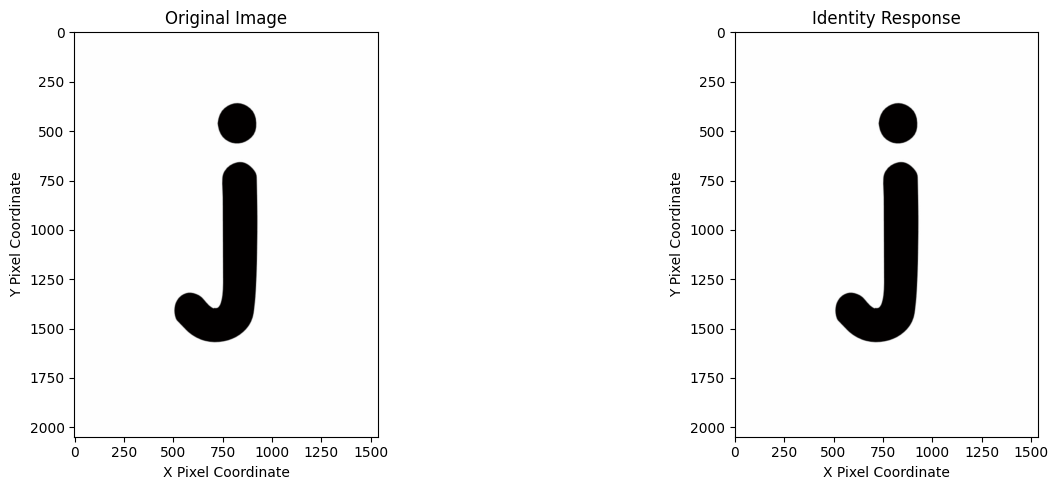

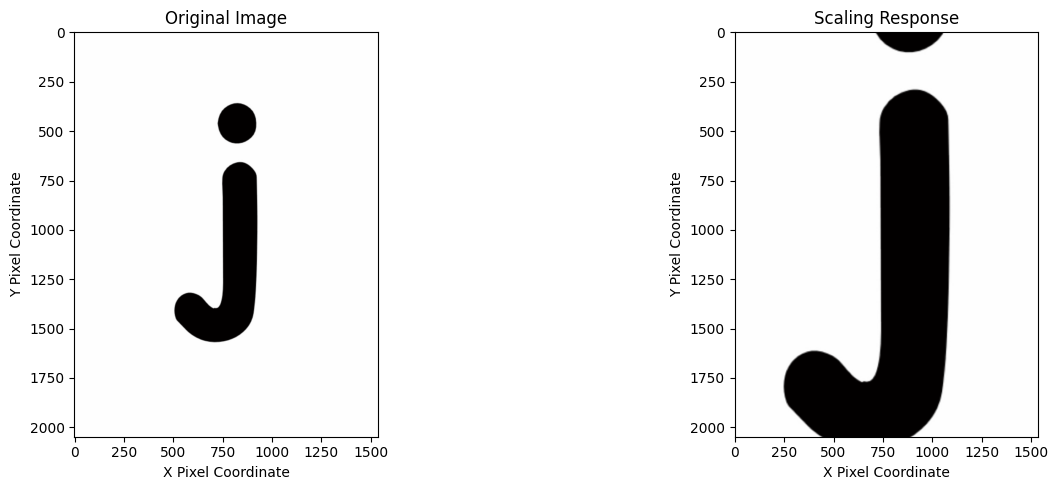

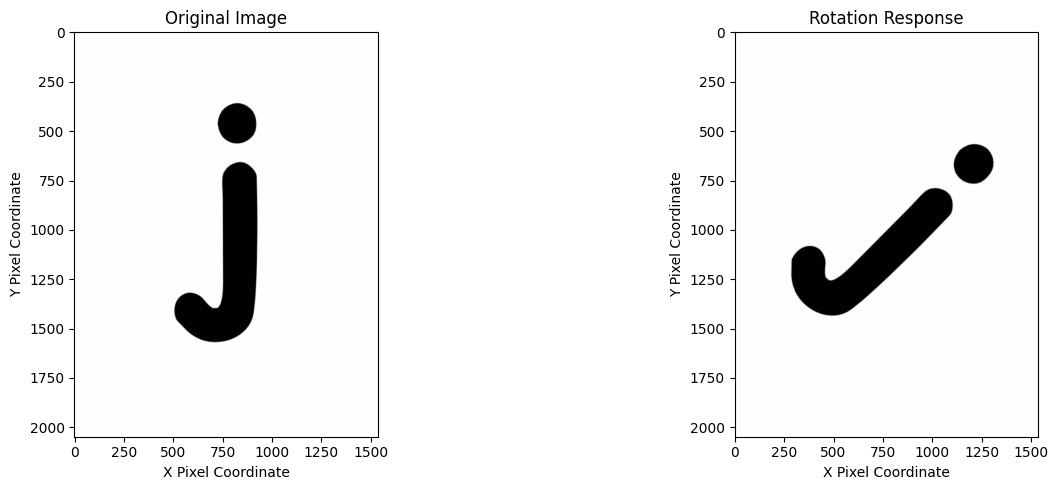

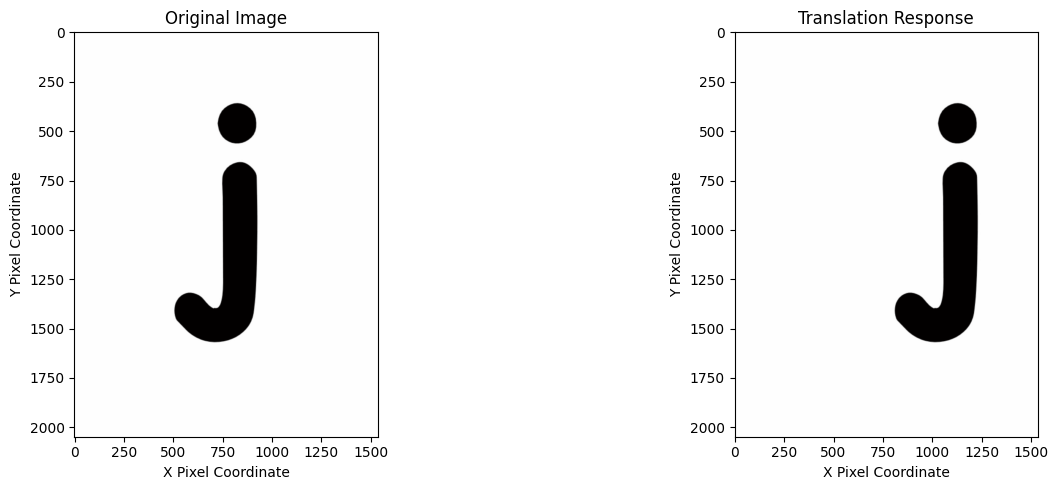

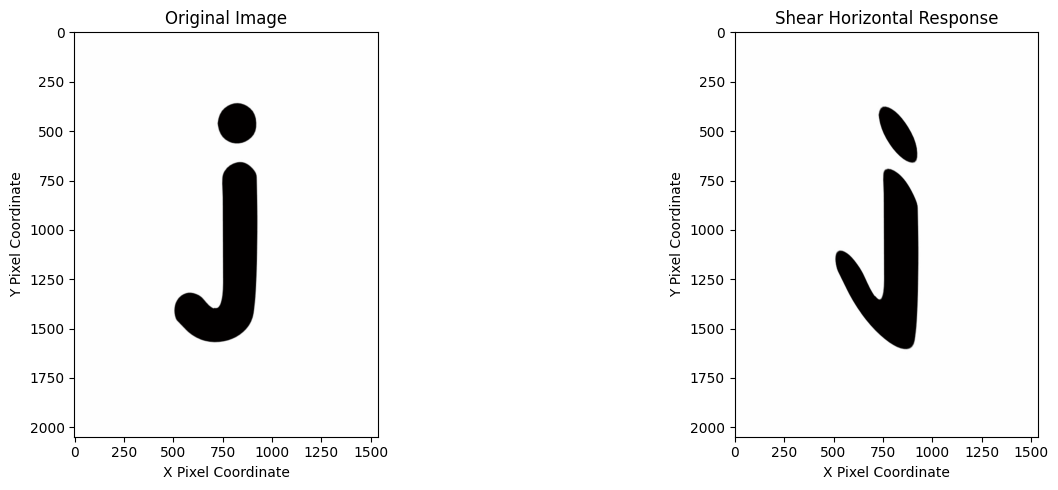

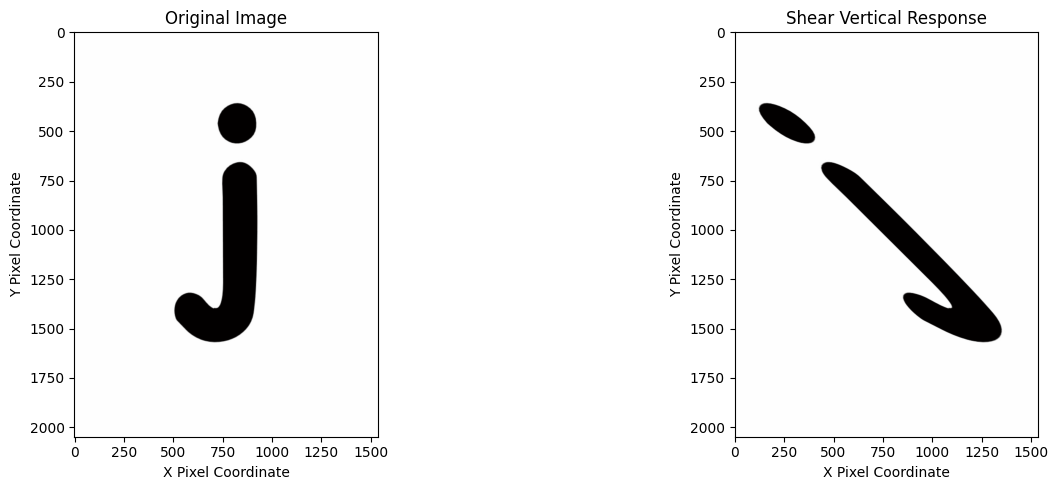

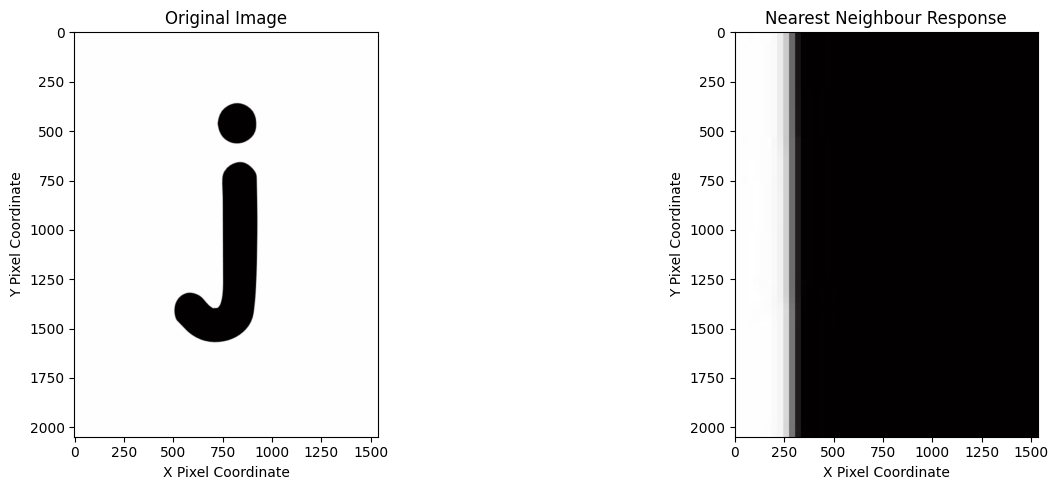

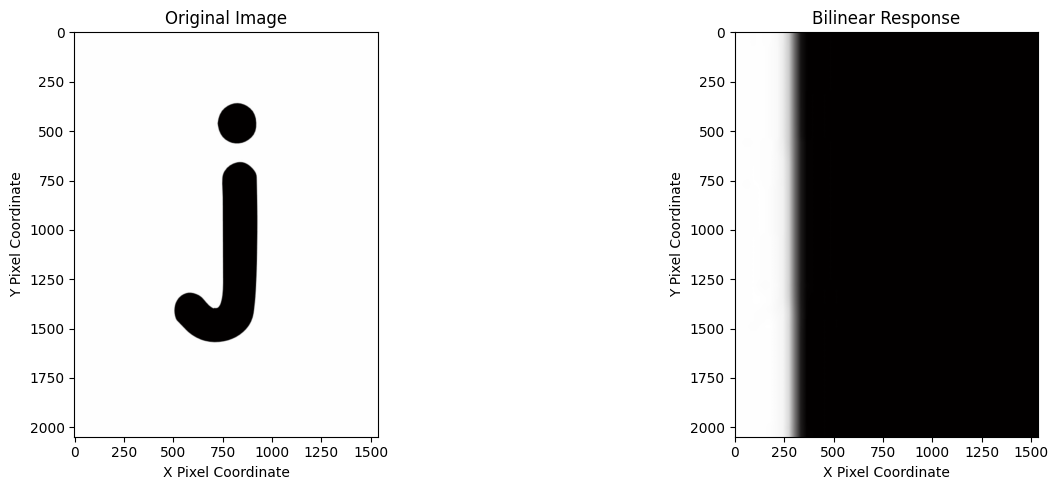

In [81]:
def bilinear_interpolation(x_dash, y_dash, image_array, height, new_height, width, new_width, mid_x, mid_y):

    old_x = float(x_dash) / float(new_width) * float(width)
    old_y = float(y_dash) / float(new_height) * float(height)

    # Get integer coordinates of the four surrounding pixels
    x1 = int(np.floor(old_x))
    y1 = int(np.floor(old_y))
    x2 = x1 + 1
    y2 = y1 + 1

    # Clamp coordinates to image bounds
    # if x1 > mid_x:
    #     x1 = max(0, min(x1, mid_x))
    # if x2 > mid_x:
    #     x2 = max(0, min(x2, mid_x))
    # if y1 > mid_y:
    #     y1 = max(0, min(y1, mid_y))
    # if y2 > mid_y:
    #     y2 = max(0, min(y2, mid_y))

    # if x1 < -mid_x:
    #     x1 = max(0, min(x1, -mid_x))
    # if x2 < -mid_x:
    #     x2 = max(0, min(x2, -mid_x))
    # if y1 < -mid_y:
    #     y1 = max(0, min(y1, -mid_y))
    # if y2 < -mid_y:
    #     y2 = max(0, min(y2, -mid_y))

    if x1 >= mid_x:
        x1 = mid_x - 1
    if y1 >= mid_y:
        y1 = mid_y - 1
    if x1 <= -mid_x:
        x1 = -mid_x + 1
    if y1 <= -mid_y:
        y1 = -mid_y + 1

    if x2 >= mid_x:
        x2 = mid_x - 1
    if y2 >= mid_y:
        y2 = mid_y - 1
    if x2 <= -mid_x:
        x2 = -mid_x + 1
    if y2 <= -mid_y:
        y2 = -mid_y + 1

    # Get fractional parts for interpolation weights
    dx = abs(old_x) - abs(x1)
    dy = abs(old_y) - abs(y1)

    # Adjust for center offset to get image array indices
    # Boundary checking in centered coordinate system (matching original logic)
    if old_x >= mid_x:
        old_x = mid_x - 1
    if old_y >= mid_y:
        old_y = mid_y - 1
    if old_x <= -mid_x:
        old_x = -mid_x + 1
    if old_y <= -mid_y:
        old_y = -mid_y + 1

    old_x = old_x + mid_x
    old_y = old_y - mid_y
    x1 = x1 + mid_x
    x2 = x2 + mid_x
    y1 = y1 - mid_y
    y2 = y2 - mid_y

    # Get the four pixel value
    if len(image_array.shape) == 3:  # Color image
        p11 = image_array[y1, x1].astype(np.float32)
        p21 = image_array[y1, x2].astype(np.float32)
        p12 = image_array[y2, x1].astype(np.float32)
        p22 = image_array[y2, x2].astype(np.float32)
    else:  # Grayscale image
        p11 = float(image_array[y1, x1])
        p21 = float(image_array[y1, x2])
        p12 = float(image_array[y2, x1])
        p22 = float(image_array[y2, x2])

    # Bilinear interpolation
    # Interpolate along x-axis first
    p1 = p11 * (1 - dx) + p21 * dx
    p2 = p12 * (1 - dx) + p22 * dx
    
    # Interpolate along y-axis
    interpolated = p1 * (1 - dy) + p2 * dy
    
    # Convert back to uint8
    if len(image_array.shape) == 3:
        return np.clip(interpolated, 0, 255).astype(np.uint8)
    else:
        return np.clip(int(interpolated), 0, 255)

def nearest_neighbour(x_dash, y_dash, height, new_height, width, new_width, mid_x, mid_y):
    # Formula:
    # sourceX = int(round(targetX / targetWidth * sourceWidth))
    # sourceY =  int(round(targetY / targetHeight * sourceHeight))

    old_x = int(round(float(x_dash)/float(new_width) * float(width)))
    old_y = int(round(float(y_dash)/float(new_height) * float(height)))

    if old_x >= mid_x:
        old_x = mid_x - 1 
    if old_y >= mid_y:
        old_y = mid_y - 1

    if old_x <= -mid_x:
        old_x = -mid_x + 1
    if old_y <= -mid_y:
        old_y = -mid_y + 1

    old_x = old_x + mid_x
    old_y = old_y - mid_y

    return old_x, old_y

def transform_image(new_row_array, image_array, mid_y, mid_x, T_inv, height, new_height, width, new_width, type_int, flag):
    for y in range(mid_y, -mid_y, -1):
        for x in range(-mid_x, mid_x, 1):

            # old_x, old_y = affine_matrix(x, y, transform_type, T)
            old_x = T_inv[0, 0] * x + T_inv[1, 0] * y + T_inv[2, 0] * 1
            old_y = T_inv[0, 1] * x + T_inv[1, 1] * y + T_inv[2, 1] * 1

            # Correct for center offset
            new_x = x + mid_x
            new_y = y - mid_y

            if type_int == "NN":
                old_x, old_y = nearest_neighbour(old_x, old_y, height, new_height, width, new_width, mid_x, mid_y)
                new_row_array[int(new_y), int(new_x)] = image_array[int(old_y), int(old_x)]
            if type_int == "BI":
                interpolated_pixel = bilinear_interpolation(old_x, old_y, image_array, height, new_height, width, new_width, mid_x, mid_y)
                new_row_array[int(new_y), int(new_x)] = interpolated_pixel

    return new_row_array

def select_transform(image_path, image_array, transform_type, integration_type, height, width, pixel_array_size, flag):
    # Keep image size
    new_height = height
    new_width = width

    # New image frame
    new_row_array = np.zeros((height, width, pixel_array_size), dtype=np.uint8)
    mid_x = int(width/2)
    mid_y = int(height/2)

    # Types of matrices:
    match transform_type:
        # 1. Identity 
        case "Identity":
            T = [[1, 0, 0],
                [0, 1, 0],
                [0, 0, 1]]
    
        # 2. Scaling 
        case "Scaling":
            if flag == 1:
                s = 30 # making 30 times bigger
            else:
                s = 2 # making 2 times bigger
            T = [[s, 0, 0],
                [0, s, 0],
                [0, 0, 1]]
    
        # 3. Rotation
        case "Rotation":
            theta = 45
            angle_rad = np.radians(theta)
            T = [[np.cos(angle_rad), np.sin(angle_rad), 0],
                [-np.sin(angle_rad), np.cos(angle_rad), 0],
                [0, 0, 1]]

        # 4. Translation
        case "Translation":
            tx = 300 # no. pixels along x
            ty = 0 # no. pixels along y
            T = [[1, 0, 0],
                [0, 1, 0],
                [tx, ty, 1]]

        # 5. Shear vertical 
        case "Shear Vertical":
            sv = 1
            T = [[1, 0, 0],
                 [sv, 1, 0],
                 [0, 0, 1]]
    
        # 6. Shear horiz 
        case "Shear Horizontal":
            sh = 1
            T = [[1, sh, 0],
                 [0, 1, 0],
                 [0, 0, 1]]
        
    match integration_type:
        case "Nearest Neighbour":
            type_int = "NN"
        case "Bilinear":
            type_int = "BI"

    # Sanity check
    # 1 = T_inv[0, 2] * x + T_inv[1, 2] * y + T_inv[2, 2] * 1

    T_inv = inv(T)
    # Choose type of interpolation method -> NN = Nearest Neighbour
    trans_image = transform_image(new_row_array, image_array, mid_y, mid_x, T_inv, height, new_height, width, new_width, type_int, flag)
    if flag == 1:
        plot_image(image_path, trans_image, integration_type)
    else:
        plot_image(image_path, trans_image, transform_type)

def plot_image(image_path, response, transform_type):
    # Visualize
    image_orig = cv2.imread(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_orig, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].set_xlabel("X Pixel Coordinate")
    axes[0].set_ylabel("Y Pixel Coordinate")

    axes[1].imshow(response, cmap='gray')
    axes[1].set_title(f"{transform_type} Response")
    axes[1].set_xlabel("X Pixel Coordinate")
    axes[1].set_ylabel("Y Pixel Coordinate")

    # axes[2].imshow(image, cmap='gray')
    # y_coords, x_coords = np.where(corners)
    # axes[2].plot(x_coords, y_coords, 'r.', markersize=5)
    # axes[2].set_title('Detected Corners')
    # axes[2].axis('off')
    # Add labels

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def main():
    image_path = 'Figures/letter_i.jpg' 
    image_array = cv2.imread(image_path)
    height, width, pixel_array_size = image_array.shape

    # transform_type = "Scaling" # "Shear_horiz" #"Translation" # "Rotation" #"Identity" # "Shear_vert"
    integration_type =  "Nearest Neighbour" # "bilinear" #  

    affine_list = ["Identity", "Scaling", "Rotation", "Translation", "Shear Horizontal", "Shear Vertical"]
    int_list = ["Nearest Neighbour", "Bilinear"]
    
    flag = None
    for transform_type in affine_list:
        select_transform(image_path, image_array, transform_type, integration_type, height, width, pixel_array_size, flag)
    
    flag = 1
    transform_type = "Scaling"
    for integration_type in int_list:
        if integration_type == "Bilinear":
            # Bilinear library
            # Enlarge image by 2x
            resized = cv2.resize(image_array, None, fx=30, fy=30, interpolation=cv2.INTER_LINEAR)

            scale = 30
            h_new = height * scale
            w_new = width * scale

            # Crop region corresponding to original 1×1 pixel area
            start_h = int(h_new/2) 
            start_w = int(w_new/2)

            cropped = resized[start_h - int(height/2):start_h + int(height/2), start_w - int(width/2):start_w + int(width/2)]
            plot_image(image_path, cropped, integration_type)

        else:
            select_transform(image_path, image_array, transform_type, integration_type, height, width, pixel_array_size, flag)

if __name__ == "__main__":
    main()

### 1.2 Intensity Transformations 
Intensity Transformations include Gamma, Log, Contrast Stretching and Intensity Level Slicing

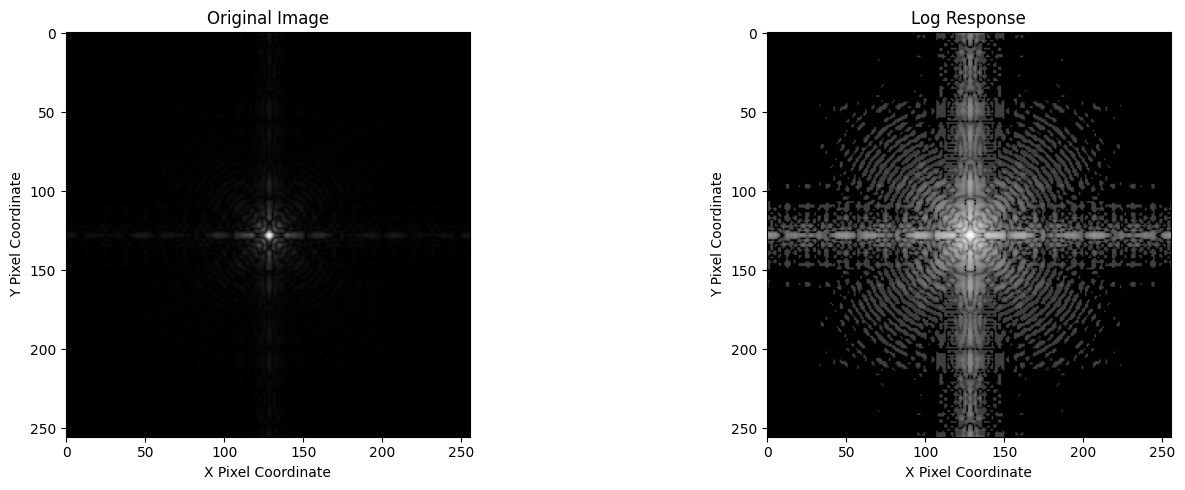

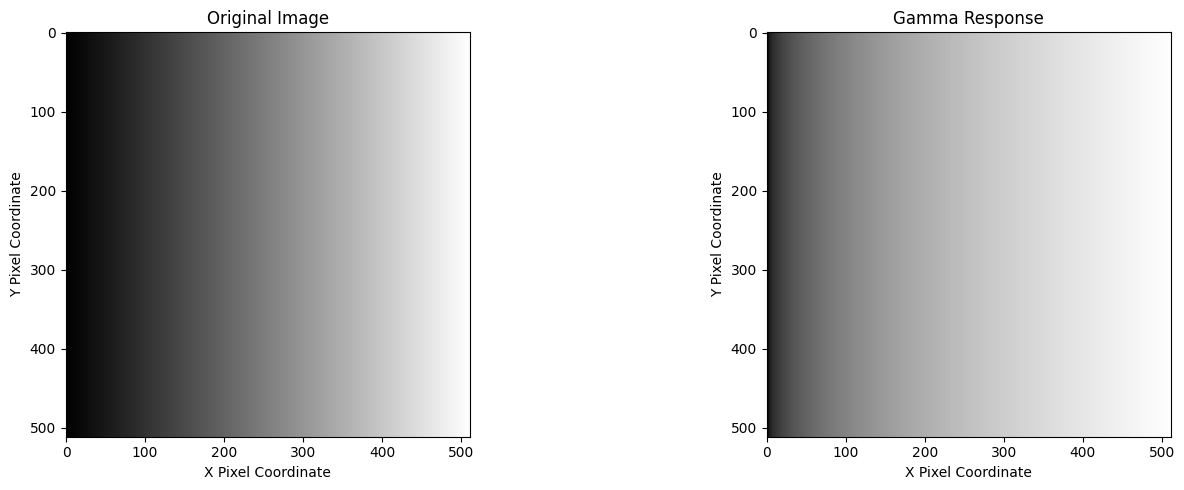

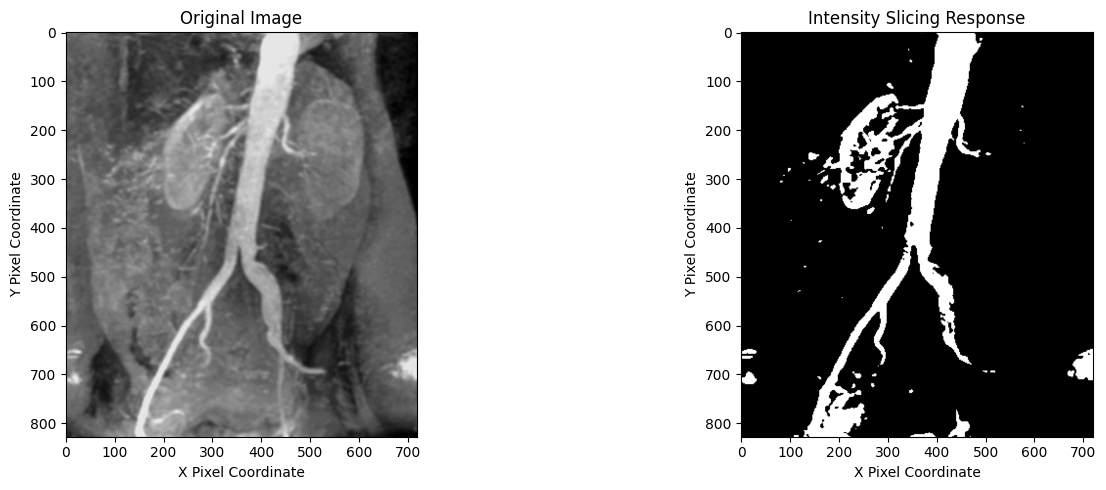

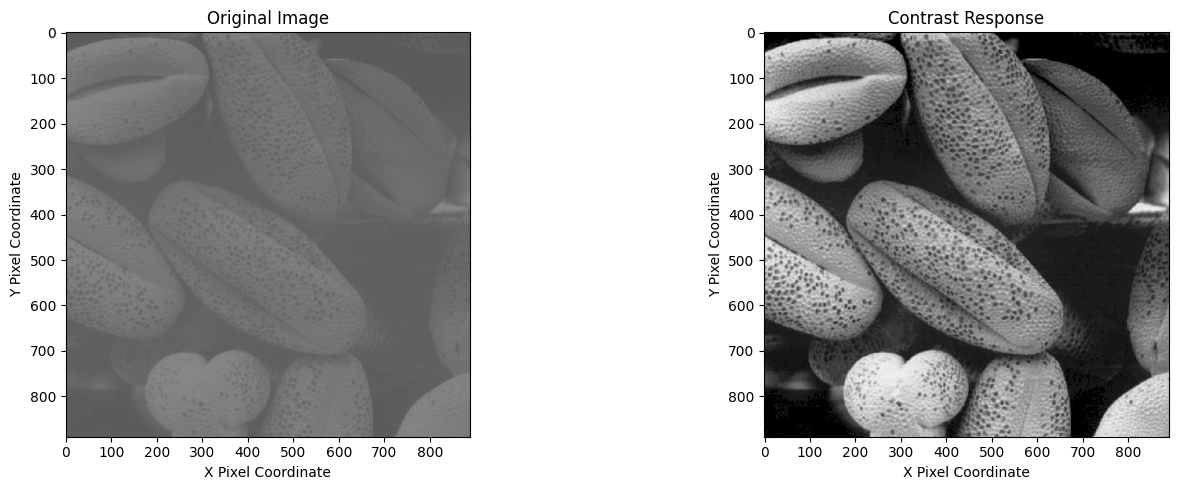

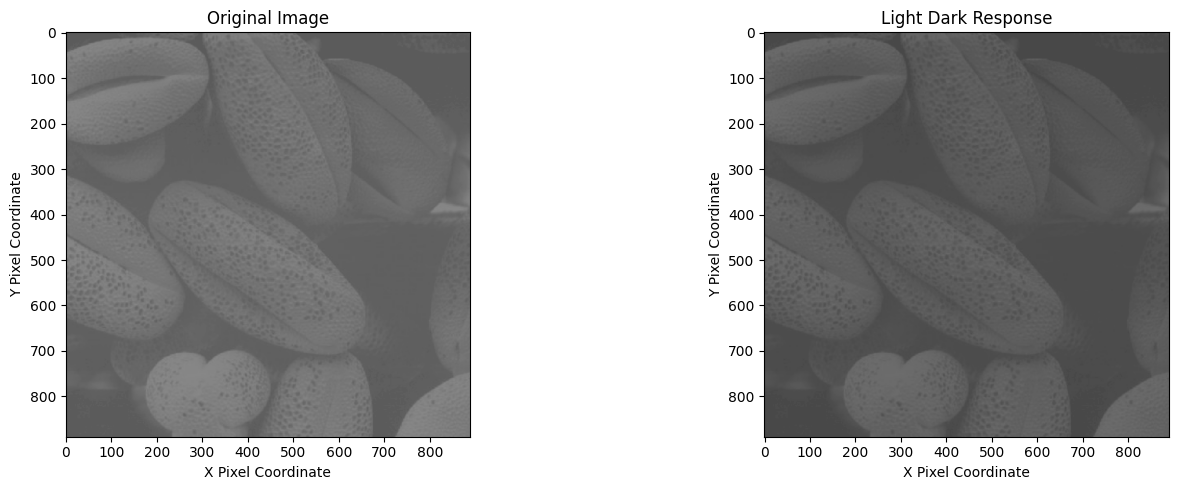

In [82]:
def log_transformation(image_array, x, y):
    pixel = image_array[y, x].astype(np.float32) 
    """
    Log transform for a single pixel. Works for both grayscale and color.
    Uses NumPy so it can handle a 3-element RGB array (math.log expects a scalar).
    """
    max_val = np.max(image_array)
    c = 255.0 / (np.log1p(max_val) / np.log(2.0))  
    
    # log base 2: log2(1 + pixel) = ln(1+pixel) / ln(2)
    s = c * (np.log1p(pixel) / np.log(2.0))

    if pixel.ndim == 0:  # grayscale pixel
        return np.uint8(np.clip(s, 0, 255))
    else:  # color pixel (length-3 array)
        return np.clip(s, 0, 255).astype(np.uint8)

def gamma_transformation(image_array, x, y):
    pixel = image_array[y, x].astype(np.float32) 
    gamma_val = 1/(2.5)
    c = 1
    s = c * 255 * (pixel / 255) ** gamma_val

    if pixel.ndim == 0:  # grayscale pixel
        return np.uint8(np.clip(s, 0, 255))
    else:  # color pixel (length-3 array)
        return np.clip(s, 0, 255).astype(np.uint8)

def contrast_stretch_transformation(image_array, x, y):
    pixel = image_array[y, x].astype(np.float32) 
    # Calc min and max values 
    min_val = np.min(image_array)
    max_val = np.max(image_array)
    c = 255.0 # -> maximum is white 
    
    # Apply contrast stretching 
    s = (pixel - min_val) * (c / (max_val - min_val))

    if pixel.ndim == 0:  # grayscale pixel
        return np.uint8(np.clip(s, 0, 255))
    else:  # color pixel (length-3 array)
        return np.clip(s, 0, 255).astype(np.uint8)

def intensity_level_slicing(image_array, x, y):
    pixel = image_array[y, x].astype(np.float32) # value in range 0 - 255 (black - white)
    # # Calc min and max values 
    # min_val = np.min(image_array)
    # max_val = np.max(image_array)
    
    # Create range -> preserve range
    A = 150
    B = 255
    C = 0

    s = []
    # for element in pixel:
    #     if (element >= A) and (element <= B):
    #         s.append(B)
    #     else:
    #         s.append(element)

    # Create range -> reduce range
    for element in pixel:
        if (element >= A) and (element <= B):
            s.append(B)
        else:
            s.append(C)


    if pixel.ndim == 0:  # grayscale pixel
        return np.uint8(np.clip(s, 0, 255))
    else:  # color pixel (length-3 array)
        return np.clip(s, 0, 255).astype(np.uint8)

def light_dark_transformation(image_array, x, y):
    pixel = image_array[y, x].astype(np.float32) 
    # Apply light and dark -> dark < 1.0 < light
    c = 0.8 # -> dark
    # c = 1.8 # -> light
    s = pixel * c

    if pixel.ndim == 0:  # grayscale pixel
        return np.uint8(np.clip(s, 0, 255))
    else:  # color pixel (length-3 array)
        return np.clip(s, 0, 255).astype(np.uint8)

def transform_image(image_path, transform_type):
    image_array = cv2.imread(image_path)
    height, width, pixel_array_size = image_array.shape
    # Plot image
    # plt.imshow(image_array, cmap='gray')
    # plt.show()

    # New image frame
    new_row_array = np.zeros((height, width, pixel_array_size), dtype=np.uint8)
    mid_x = int(width/2)
    mid_y = int(height/2)

    match transform_type:
        case "Log":
            for y in range(0, height, 1):
                for x in range(0, width, 1):
                    pixel = log_transformation(image_array, x, y)
                    new_row_array[y, x] = pixel

        case "Gamma":
            for y in range(0, height, 1):
                for x in range(0, width, 1):
                    pixel = gamma_transformation(image_array, x, y)
                    new_row_array[y, x] = pixel

        case "Contrast":
            for y in range(0, height, 1):
                for x in range(0, width, 1):
                    pixel = contrast_stretch_transformation(image_array, x, y)
                    new_row_array[y, x] = pixel

        case "Intensity Slicing":
            for y in range(0, height, 1):
                for x in range(0, width, 1):
                    pixel = intensity_level_slicing(image_array, x, y)
                    new_row_array[y, x] = pixel

        case "Light Dark":
            for y in range(0, height, 1):
                for x in range(0, width, 1):
                    pixel = light_dark_transformation(image_array, x, y)
                    new_row_array[y, x] = pixel

    # plt.imshow(new_row_array)
    # plt.show()

    plot_image(image_path, new_row_array, transform_type)
    return new_row_array

def test(image_array, height, width, array_size):
     # New image frame
    new_row_array = np.zeros((height, width, array_size), dtype=np.uint8)
    mid_x = int(width/2)
    mid_y = int(height/2)

    for y in range(0, height, 1):
            for x in range(0, width, 1):
                pixel = intensity_level_slicing(image_array, x, y)
                new_row_array[y, x] = pixel


    plt.imshow(new_row_array)
    plt.show()

def clamp_vals(x_test, y_test, width, height):
    # if x_test > width:
    #     return False
    # if x_test < 0:
    #     return False
    # if y_test > height:
    #     return False
    # if y_test < 0:
    #     return False
    # else:
    #     return True

    val_x = val_y = True

    if x_test >= width:
        val_x = False
    if x_test < 0:
        val_x = False
    if y_test >= height:
        val_y = False
    if y_test < 0:
        val_y = False

    if (val_x == False) or (val_y == False):
        return False
    else:
        return True

def choose_transform(transform_type):
    match transform_type:
        case "Log":
            image_path = 'Figures/fourier_spectrum.png' 
            new_image_arr = transform_image(image_path, transform_type)

        case "Gamma":
            image_path = 'Figures/intensity_ramp.png' 
            new_image_arr = transform_image(image_path, transform_type)

        case "Contrast":
            image_path = 'Figures/contrast_stretching.png' 
            new_image_arr = transform_image(image_path, transform_type)

        case "Intensity Slicing":
            image_path = 'Figures/intensity_level.png' 
            new_image_arr = transform_image(image_path, transform_type)

        case "Light Dark":
            image_path = 'Figures/contrast_stretching.png' 
            new_image_arr = transform_image(image_path, transform_type)
        
        case None:
            print("No transformation")

def plot_image(image_path, response, transform_type):
    # Visualize
    image_orig = cv2.imread(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_orig, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].set_xlabel("X Pixel Coordinate")
    axes[0].set_ylabel("Y Pixel Coordinate")

    axes[1].imshow(response, cmap='gray')
    axes[1].set_title(f"{transform_type} Response")
    axes[1].set_xlabel("X Pixel Coordinate")
    axes[1].set_ylabel("Y Pixel Coordinate")

    # axes[2].imshow(image, cmap='gray')
    # y_coords, x_coords = np.where(corners)
    # axes[2].plot(x_coords, y_coords, 'r.', markersize=5)
    # axes[2].set_title('Detected Corners')
    # axes[2].axis('off')
    # Add labels

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def main():
    transforms = ["Log", "Gamma", "Intensity Slicing", "Contrast", "Light Dark"]
    for transform_type in transforms:
        transformed_image = choose_transform(transform_type)
        
if __name__ == "__main__":
    main()

### 1.4 Histograms
The Basic Histogram, Global Histogram Equalisation, and Local Histogram Equalisation are explored below.

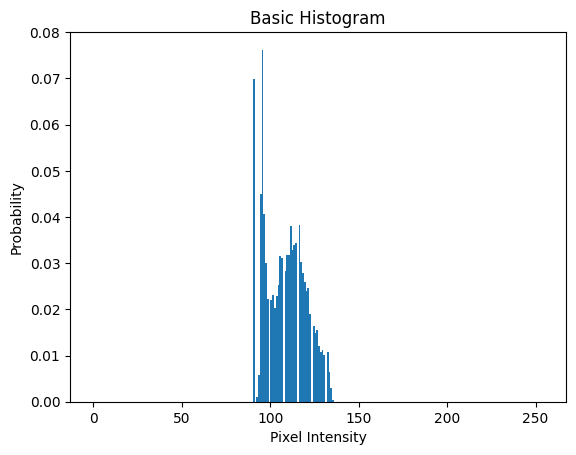

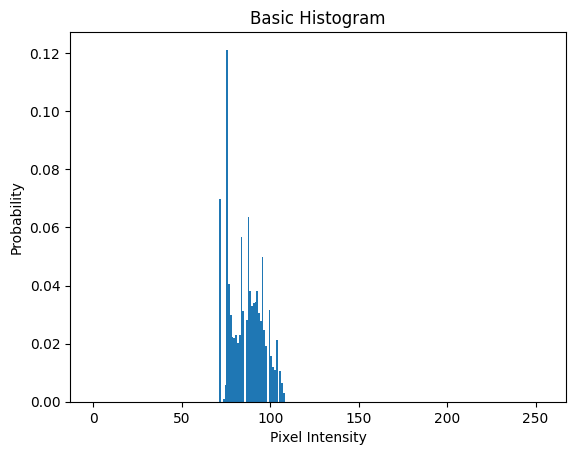

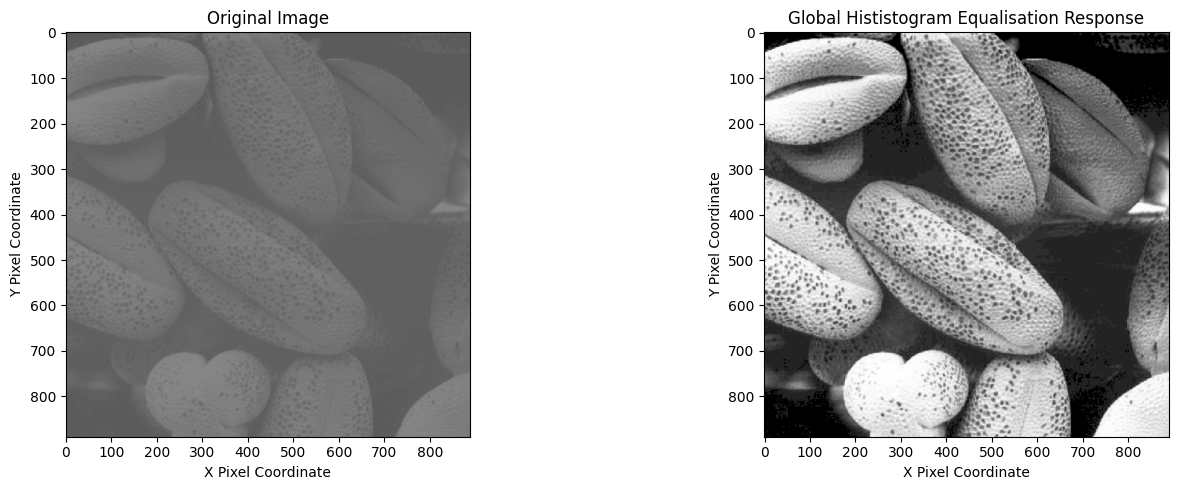

In [ ]:
def light_dark_transformation(image_array, x, y, c):
    pixel = image_array[y, x].astype(np.float32) 
    # Apply light and dark -> dark < 1.0 < light
    s = pixel * c

    if pixel.ndim == 0:  # grayscale pixel
        return np.uint8(np.clip(s, 0, 255))
    else:  # color pixel (length-3 array)
        return np.clip(s, 0, 255).astype(np.uint8)

def light_dark(image_path, c):
    image_array = cv2.imread(image_path)
    height, width, pixel_array_size = image_array.shape
    # Plot image
    # plt.imshow(image_array, cmap='gray')
    # plt.show()

    # New image frame
    new_row_array = np.zeros((height, width, pixel_array_size), dtype=np.uint8)
    mid_x = int(width/2)
    mid_y = int(height/2)
    for y in range(0, height, 1):
        for x in range(0, width, 1):
            pixel = light_dark_transformation(image_array, x, y, c)
            new_row_array[y, x] = pixel
    
    return new_row_array

def plot_hist(new_image_arr, L):
    # Handle both numpy arrays and lists of pixels
    if isinstance(new_image_arr, np.ndarray):
        # If it's a numpy array (3D image), extract R channel
        gray_values = new_image_arr[:, :, 0]   # take R channel
        # Flatten to 1D for histogram
        gray_values = gray_values.flatten()
    else:
        # If it's a list of pixels, extract R channel (first element) from each pixel
        gray_values = np.array([pixel[0] for pixel in new_image_arr])

    # plt.hist(gray_values, bins=L, range=(0, L-1))
    # plt.xlabel("Pixel Intensity")
    # plt.ylabel("Frequency")
    # plt.show()

    # plt.hist(gray_values, bins=L, range=(0, L-1), density=True)
    # plt.xlabel("Pixel Intensity")
    # plt.ylabel("Probability Density")
    # plt.show()

    counts, bin_edges = np.histogram(
    gray_values,
    bins=L,
    range=(0, L-1)
    )

    # print(counts)

    return counts, gray_values

def get_pixels(array_region, num_pixels, L):
    counts, hist_vals = plot_hist(array_region, L)
    MN = num_pixels

    CDF = np.zeros(len(counts))
    p_r = np.zeros(len(counts))

    for i in range(0, len(counts)):
        p_r[i] = counts[i] / MN

    # print(p_r)

    for i in range(0, len(p_r)):
        if i == 0:
            CDF[0] = p_r[0]
        else:
            CDF[i] = p_r[i] + CDF[i-1]

    CDF = (L-1) * CDF

    # print(CDF)

    # Rounded
    s = [int(round(p)) for p in CDF]  # take R channel

    return s

def global_hist_equalisation(counts, hist_vals, new_image_arr, L):
    height, width, pixel_array_size = new_image_arr.shape
    hist_row_array = np.zeros((height, width, pixel_array_size), dtype=np.uint8)
 
    # MN = 889
    MN = len(new_image_arr)

    CDF = np.zeros(len(counts))
    p_r = np.zeros(len(counts))

    for i in range(0, len(counts)):
        p_r[i] = counts[i] / MN

    for i in range(0, len(p_r)):
        if i == 0:
            CDF[0] = p_r[0]
        else:
            CDF[i] = p_r[i] + CDF[i-1]

    CDF = (L-1) * CDF
    # print(CDF)

    # Rounded
    s = [int(round(p)) for p in CDF]  # take R channel

    print(s)

    for y in range(0, height, 1):
        for x in range(0, width, 1):
            pixel = new_image_arr[y, x]
            replace_val = pixel[0] - 1 
            hist_row_array[y, x] = s[replace_val]

            if hist_row_array[y, x].ndim == 0:  # grayscale pixel
                hist_row_array[y, x] = np.uint8(np.clip(s, 0, 255))
            else:  # color pixel (length-3 array)
                hist_row_array[y, x] = np.clip(hist_row_array[y, x], 0, 255).astype(np.uint8)

    plt.imshow(hist_row_array)
    plt.show()

def local_hist_equalisation(new_image_arr, L, m):
    height, width, pixel_array_size = new_image_arr.shape
    hist_row_array = np.zeros((height, width, pixel_array_size), dtype=np.uint8)
    
    for y in range(0, height, 1):
        for x in range(0, width, 1):
            num_pixels = 0
            p_array = []

            # for y_m in range(0, m, 1):
            #     for x_m in range(0, m, 1):
            #         check = clamp_vals((x + x_m), (y + y_m), width, height)
            #         if check == True:
            #             p_array.append(new_image_arr[(y + y_m), (x + x_m)])
            #             num_pixels += 1

            # Get surrounding co-ordinates
            pixel = new_image_arr[y, x]
            p_array.append(pixel)
            num_pixels += 1

            # Get up co-ordinate
            x_up = x
            y_up = y - 1
            check = clamp_vals(x_up, y_up, width, height)
            if check == True:
                p_array.append(new_image_arr[y_up, x_up])
                num_pixels += 1

            # Get up right co-ordinate
            x_up_right = x + 1
            y_up_right = y - 1
            check = clamp_vals(x_up_right, y_up_right, width, height)
            if check == True:
                p_array.append(new_image_arr[y_up_right, x_up_right])
                num_pixels += 1
            
            # Get right co-ordinate
            x_right = x + 1
            y_right = y
            check = clamp_vals(x_right, y_right, width, height)
            if check == True:
                p_array.append(new_image_arr[y_right, x_right])
                num_pixels += 1

            # Get right down co-ordinate
            x_down_right = x + 1
            y_down_right = y + 1
            check = clamp_vals(x_down_right, y_down_right, width, height)
            if check == True:
                p_array.append(new_image_arr[y_down_right, x_down_right])
                num_pixels += 1

            # Get down co-ordinate
            x_down = x
            y_down = y + 1
            check = clamp_vals(x_down, y_down, width, height)
            if check == True:
                p_array.append(new_image_arr[y_down, x_down])
                num_pixels += 1

            # Get down left co-ordinate
            x_down_left = x - 1
            y_down_left = y + 1
            check = clamp_vals(x_down_left, y_down_left, width, height)
            if check == True:
                p_array.append(new_image_arr[y_down_left, x_down_left])
                num_pixels += 1

            # Get left co-ordinate
            x_left = x - 1
            y_left = y 
            check = clamp_vals(x_left, y_left, width, height)
            if check == True:
                p_array.append(new_image_arr[y_left, x_left])
                num_pixels += 1

            # Get left up co-ordinate
            x_up_left = x - 1
            y_up_left = y - 1
            check = clamp_vals(x_up_left, y_up_left, width, height)
            if check == True:
                p_array.append(new_image_arr[y_up_left, x_up_left])
                num_pixels += 1

            s = get_pixels(p_array, num_pixels, L)

            pixel = new_image_arr[y, x]
            replace_val = pixel[0] 
            hist_row_array[y, x] = s[replace_val]

            if hist_row_array[y, x].ndim == 0:  # grayscale pixel
                hist_row_array[y, x] = np.uint8(np.clip(s, 0, 255))
            else:  # color pixel (length-3 array)
                hist_row_array[y, x] = np.clip(hist_row_array[y, x], 0, 255).astype(np.uint8)
 
            # print(hist_row_array[y, x])

    # plt.imshow(hist_row_array)
    # plt.show()
    return hist_row_array

def choose_hist(image_path, new_image_arr, histogram):
    match histogram:
        case "Basic Histogram":
            L = 256
            counts, hist_vals = plot_hist(new_image_arr, L)
            # plot_image(image_path, hist_vals, histogram)
            # Normalised 

            hist, bins = np.histogram(hist_vals, bins=L, range=(0, L-1))
            hist_norm = hist / hist.sum()  # sums to 1
            plt.bar(bins[:-1], hist_norm, width=1)
            plt.xlabel("Pixel Intensity")
            plt.ylabel("Probability")
            plt.title("Basic Histogram")
            plt.show()

        case "Global Hististogram Equalisation":
            image_path = 'Figures/contrast_stretching.png' 
            c = 0.8 # -> dark
            # c = 1.8 # -> light
            new_image_arr = light_dark(image_path, c)
            L = 256 # no. levels
            counts, hist_vals = plot_hist(new_image_arr, L)
            # global_hist_equalisation(counts, hist_vals, new_image_arr, L)
            
            hist, bins = np.histogram(hist_vals, bins=L, range=(0, L-1))
            hist_norm = hist / hist.sum()  # sums to 1
            plt.bar(bins[:-1], hist_norm, width=1)
            plt.xlabel("Pixel Intensity")
            plt.ylabel("Probability")
            plt.title("Basic Histogram")
            plt.show()
            
            # Library
            equ = cv2.equalizeHist(new_image_arr[:, :, 0])
            plot_image(image_path, equ, histogram)

            # # Create figure and axis
            # fig, ax = plt.subplots()

            # # Add labels
            # ax.set_xlabel("X Pixel Coordinate")
            # ax.set_ylabel("Y Pixel Coordinate")

            # # Save
            # save_path = "/Users/anthea/Documents/GitHub/EAI733/Assignment_1/Results/"
            # fig.savefig(f"{save_path}intensity_hist_global.pdf", bbox_inches="tight")
            # plt.close(fig)

        case "Local Histogram Equalisation":
            L = 256 # no. levels
            m = 3
            image_path = 'Figures/local_histogram_processing.png'
            image_array = cv2.imread(image_path)

            output_array = local_hist_equalisation(image_array, L, m)
            plot_image(image_path, output_array, histogram)
            
def plot_image(image_path, response, transform_type):
    # Visualize
    image_orig = cv2.imread(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_orig, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].set_xlabel("X Pixel Coordinate")
    axes[0].set_ylabel("Y Pixel Coordinate")

    axes[1].imshow(response, cmap='gray')
    axes[1].set_title(f"{transform_type} Response")
    axes[1].set_xlabel("X Pixel Coordinate")
    axes[1].set_ylabel("Y Pixel Coordinate")

    # axes[2].imshow(image, cmap='gray')
    # y_coords, x_coords = np.where(corners)
    # axes[2].plot(x_coords, y_coords, 'r.', markersize=5)
    # axes[2].set_title('Detected Corners')
    # axes[2].axis('off')
    # Add labels

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def main():
    image_path = 'Figures/contrast_stretching.png' 
    new_image_arr = cv2.imread(image_path)
    histogram_types = ["Basic Histogram", "Global Hististogram Equalisation", "Local Histogram Equalisation"] 
    for histogram in histogram_types:
        choose_hist(image_path, new_image_arr, histogram)

if __name__ == "__main__":
    main()

### 1.5 Spatial and Frequency Filters
For spatial filtering, Uniform Neighbourhood Averaging, Gaussian, Min, Max and Median Filters, as well as X and Y Directed Sobel, and Laplacian Filters were explored. Thereafter, frequency filtering was performed by assessing the effects of aliasing, and performing high-pass and low-pass Butterworth filtering.

#### 1.5.1 Spatial Filtering

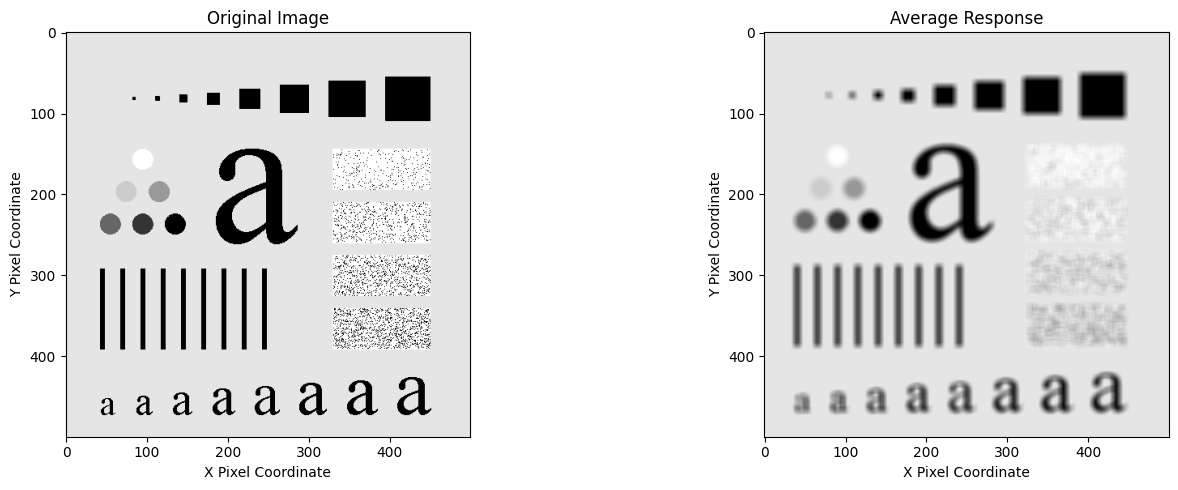

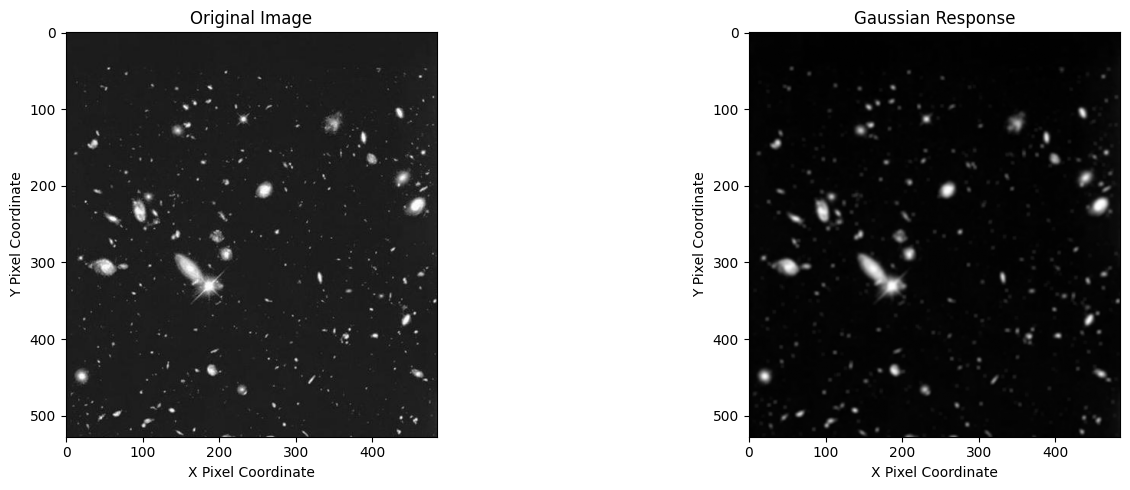

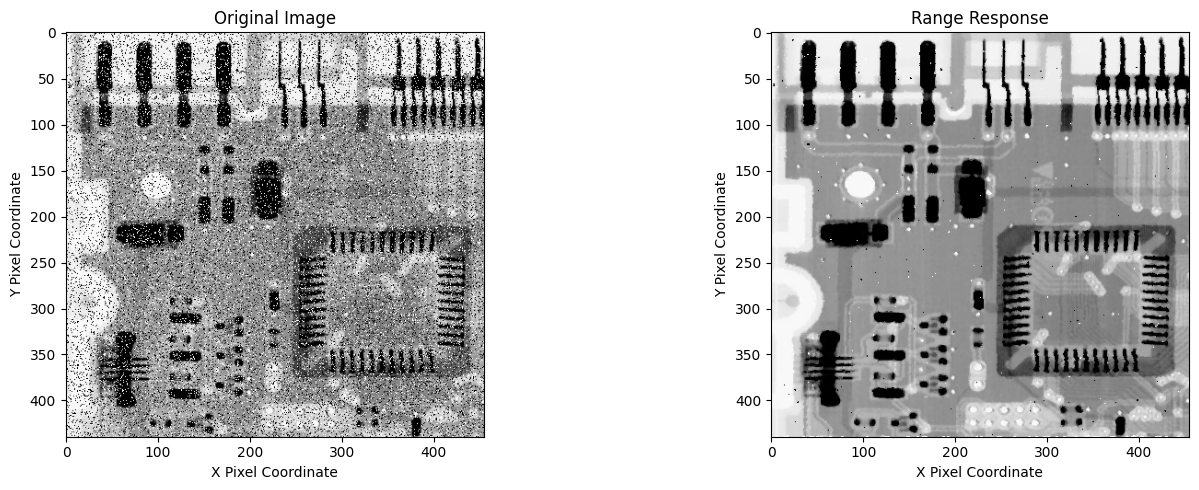

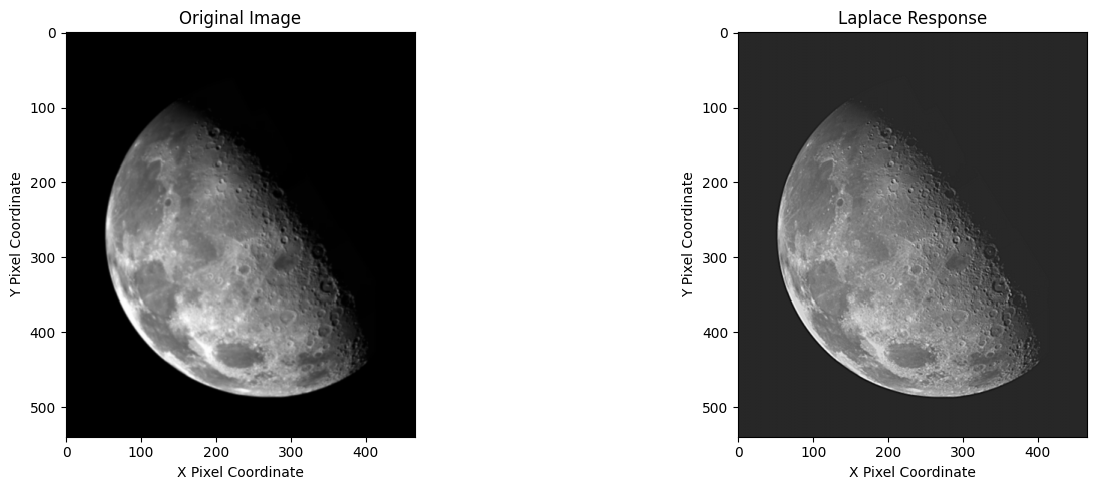

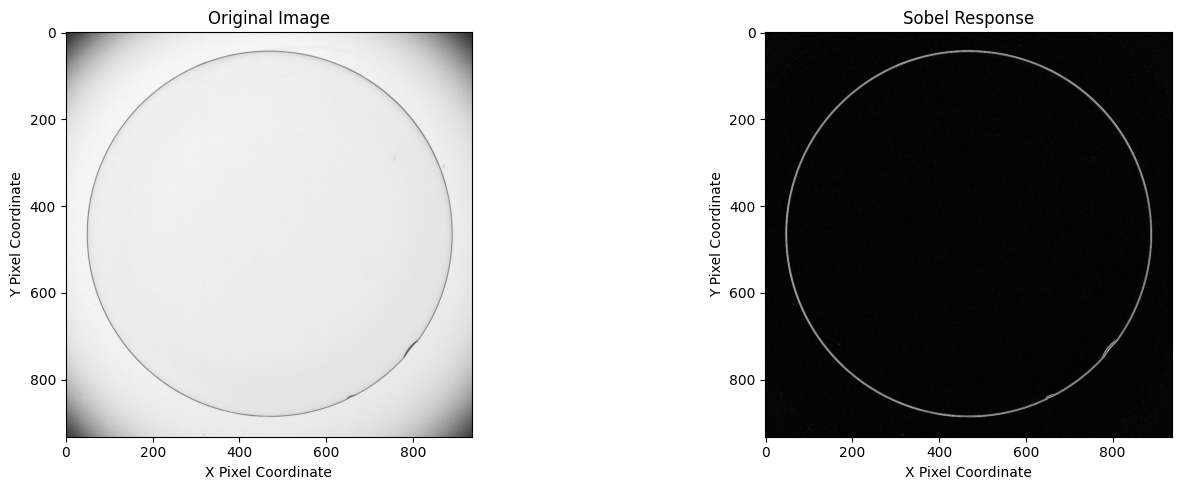

In [ ]:
def filter_image(image_path, filter_type, m):
    image_array = cv2.imread(image_path)
    height, width, pixel_array_size = image_array.shape
    
    # Keep image size
    new_height = height
    new_width = width

    # New image frame
    new_row_array = np.zeros((height, width, pixel_array_size), dtype=np.uint8)
    mid_x = int(width/2)
    mid_y = int(height/2)

    match filter_type:
        case "Average":
            new_array = uniform_neighbourhood_averaging(image_array, m)

        case "Gaussian":
            # Apply Gaussian filter
            kernel_size = 5
            sigma = 3
            blurred = gaussian_filter_rgb(image_array, kernel_size, sigma)
            # Clip values to valid range
            new_array = np.clip(blurred, 0, 255)

        case "Range":
            range_type = "median" # "max" # "min" #
            new_array = calc_median_min_max(image_array, m, range_type)

        case "Laplace":
            type_laplace = "basic" # "diagonal" # "literature" #
            new_array = laplace(image_array, type_laplace)    

        case "Sobel":
            new_array = x_y_sobel(image_array)

    plot_image(image_path, new_array, filter_type)

def plot_image(image_path, response, transform_type):
    # Visualize
    image_orig = cv2.imread(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_orig, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].set_xlabel("X Pixel Coordinate")
    axes[0].set_ylabel("Y Pixel Coordinate")

    axes[1].imshow(response, cmap='gray')
    axes[1].set_title(f"{transform_type} Response")
    axes[1].set_xlabel("X Pixel Coordinate")
    axes[1].set_ylabel("Y Pixel Coordinate")

    # axes[2].imshow(image, cmap='gray')
    # y_coords, x_coords = np.where(corners)
    # axes[2].plot(x_coords, y_coords, 'r.', markersize=5)
    # axes[2].set_title('Detected Corners')
    # axes[2].axis('off')
    # Add labels

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def uniform_neighbourhood_averaging(image_array, m):
    height, width, pixel_array_size = image_array.shape
    average_array = np.zeros((height, width, pixel_array_size), dtype=np.uint8)
    
    for y in range(0, height, 1):
        for x in range(0, width, 1):
            num_pixels = 0
            p_array = []

            for y_m in range(0, m, 1):
                for x_m in range(0, m, 1):
                    check = clamp_vals((x + x_m), (y + y_m), width, height)
                    if check == True:
                        p_array.append(image_array[(y + y_m), (x + x_m)])
                        num_pixels += 1

            s = calc_average(p_array, num_pixels) 
            average_array[y, x] = s

            if average_array[y, x].ndim == 0:  # grayscale pixel
                average_array[y, x] = np.uint8(np.clip(s, 0, 255))
            else:  # color pixel (length-3 array)
                average_array[y, x] = np.clip(average_array[y, x], 0, 255).astype(np.uint8)
    
    return average_array

def gaussian_kernel(size, sigma):
    """Create a 2D Gaussian kernel"""
    # Create coordinate grids
    ax = np.arange(-size // 2 + 1, size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    # Gaussian formula
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel_norm = kernel / np.sum(kernel)
    # print(xx)
    # print(yy)
    # print(kernel_norm)

    # Normalize so sum = 1
    return kernel / np.sum(kernel)

def convolve2d(image, kernel, convolve_type):
    """Manual 2D convolution"""
    # Get dimensions
    img_height, img_width = image.shape
    kernel_size = kernel.shape[0]
    pad = kernel_size // 2
    
    # Pad the image to handle borders
    padded = np.pad(image, pad, mode='edge')

    # Output array
    if convolve_type == "gaussian":
        output = np.zeros_like(image)
    elif convolve_type == "laplace" or convolve_type == "sobel":
        output = np.zeros_like(image, dtype=np.float64)
    
    # Perform convolution
    for i in range(img_height):
        for j in range(img_width):
            # Extract region
            region = padded[i:i+kernel_size, j:j+kernel_size]
            # Apply kernel (element-wise multiply and sum)
            output[i, j] = np.sum(region * kernel)
    
    return output

def gaussian_filter_rgb(image, kernel_size, sigma):
    """Apply Gaussian filter to RGB image"""
    # Create the Gaussian kernel
    kernel = gaussian_kernel(kernel_size, sigma)
    
    # Apply to each color channel separately
    filtered = np.zeros_like(image, dtype=np.float64)
    
    channel = 0  # R, G, B
    filtered = convolve2d(image[:, :, channel], kernel, convolve_type="gaussian")
    
    return filtered

def clamp_vals(x_test, y_test, width, height):
    val_x = val_y = True

    if x_test >= width:
        val_x = False
    if x_test < 0:
        val_x = False
    if y_test >= height:
        val_y = False
    if y_test < 0:
        val_y = False

    if (val_x == False) or (val_y == False):
        return False
    else:
        return True

def calc_average(array_region, num_pixels):
    if isinstance(array_region, np.ndarray):
        # If it's a numpy array (3D image), extract R channel
        gray_values = array_region[:, :, 0]   # take R channel
        # Flatten to 1D for histogram
        gray_values = gray_values.flatten()
    else:
        # If it's a list of pixels, extract R channel (first element) from each pixel
        gray_values = [int(pixel[0]) for pixel in array_region]

    R = 1/num_pixels
    sum = 0

    for val in gray_values:
        sum = sum + val
    
    average_value = np.uint8(R * sum)
    return average_value

def order_pixels(p_array):
    if isinstance(p_array, np.ndarray):
        # If it's a numpy array (3D image), extract R channel
        gray_values = p_array[:, :, 0]   # take R channel
        # Flatten to 1D for histogram
        gray_values = gray_values.flatten()
    else:
        # If it's a list of pixels, extract R channel (first element) from each pixel
        gray_values = [int(pixel[0]) for pixel in p_array]
    
    sorted_array = sorted(gray_values)
    return sorted_array

def calc_median_min_max(image_array, m, range_type):
    height, width, pixel_array_size = image_array.shape
    average_array = np.zeros((height, width, pixel_array_size), dtype=np.uint8)
    
    for y in range(0, height, 1):
        for x in range(0, width, 1):
            num_pixels = 0
            p_array = []

            for y_m in range(0, m, 1):
                for x_m in range(0, m, 1):
                    check = clamp_vals((x + x_m), (y + y_m), width, height)
                    if check == True:
                        p_array.append(image_array[(y + y_m), (x + x_m)])
                        num_pixels += 1     
            
            ordered = order_pixels(p_array)
            if range_type == "min":
                s = ordered[0]
            elif range_type == "max":
                s = ordered[-1]
            elif range_type == "median":
                s = ordered[round(len(p_array)/2)]

            average_array[y, x] = s

            if average_array[y, x].ndim == 0:  # grayscale pixel
                average_array[y, x] = np.uint8(np.clip(s, 0, 255))
            else:  # color pixel (length-3 array)
                average_array[y, x] = np.clip(average_array[y, x], 0, 255).astype(np.uint8)
    
    return average_array

def laplace(image_array, type_laplace):
    match type_laplace:
        case "basic":
            kernel = np.array([ [0, 1, 0],
                                [1, -4, 1],
                                [0, 1, 0]], dtype=np.float64)
            
        case "diagonal":
            kernel = np.array([ [0, 1, 0],
                                [1, -4, 1],
                                [0, 1, 0]], dtype=np.float64)
            
        case "literature":
            kernel = np.array([ [0, -1, 0],
                                [-1, 4, -1],
                                [0, -1, 0]], dtype=np.float64)
            
    # Apply to each color channel separately
    filtered = np.zeros_like(image_array, dtype=np.float64)
    
    channel = 0  # R, G, B
    filtered = convolve2d(image_array[:, :, channel], kernel, convolve_type="laplace")

    # plt.imshow(filtered, cmap='gray')
    # plt.show()

    # # Create figure and axis
    # fig, ax = plt.subplots()

    # ax.imshow(filtered, cmap='gray')

    # # Add labels
    # ax.set_xlabel("X Pixel Coordinate")
    # ax.set_ylabel("Y Pixel Coordinate")

    # # Save
    # save_path = "/Users/anthea/Documents/GitHub/EAI733/Assignment_1/Results/"
    # fig.savefig(f"{save_path}spatial_filt_laplace_mask.pdf", bbox_inches="tight")
    # plt.close(fig)

    match type_laplace:
        case "basic":
            filtered = image_array[:, :, channel] - filtered

        case "diagonal":
            filtered = image_array[:, :, channel] + filtered

        case "literature":
            filtered = image_array[:, :, channel] - filtered

    return filtered
    
def x_y_sobel(image_array):
    # Apply to each color channel separately
    filtered = np.zeros_like(image_array, dtype=np.float64)
    channel = 0  # R, G, B

    kernel = np.array([ [-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float64)
    filtered_x = convolve2d(image_array[:, :, channel], kernel, convolve_type="sobel")
    

    kernel = np.array([ [-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=np.float64)
    filtered_y = convolve2d(image_array[:, :, channel], kernel, convolve_type="sobel")

    filtered = np.sqrt(filtered_x ** 2 + filtered_y ** 2)
    return filtered

def choose_filter(filter_type):
    match filter_type:
        case "Average":
            m = 9
            image_path = 'Figures/spatial_filtering.png' 
            filter_image(image_path, filter_type, m)

        case "Gaussian":
            m = 3
            image_path = 'Figures/gaussian.png' 
            filter_image(image_path, filter_type, m)

        case "Range":
            m = 3
            image_path = 'Figures/min_max_median.png' 
            filter_image(image_path, filter_type, m)

        case "Laplace":
            m = None
            image_path = 'Figures/laplace.png' 
            filter_image(image_path, filter_type, m)
            # image_array = cv2.imread(image_path)
            # laplacian = cv2.Laplacian(image_array[:, :, 0], cv2.CV_64F)
            # cv2.imwrite("laplacian.png", laplacian)

        case "Sobel":
            m = None
            image_path = 'Figures/sobel.png' 
            filter_image(image_path, filter_type, m)

def main():
    filter_type = ["Average", "Gaussian", "Range", "Laplace", "Sobel"]
    for filter in filter_type:
        choose_filter(filter)
    
if __name__ == "__main__":
    main()

#### 1.5.2 Frequency Filtering

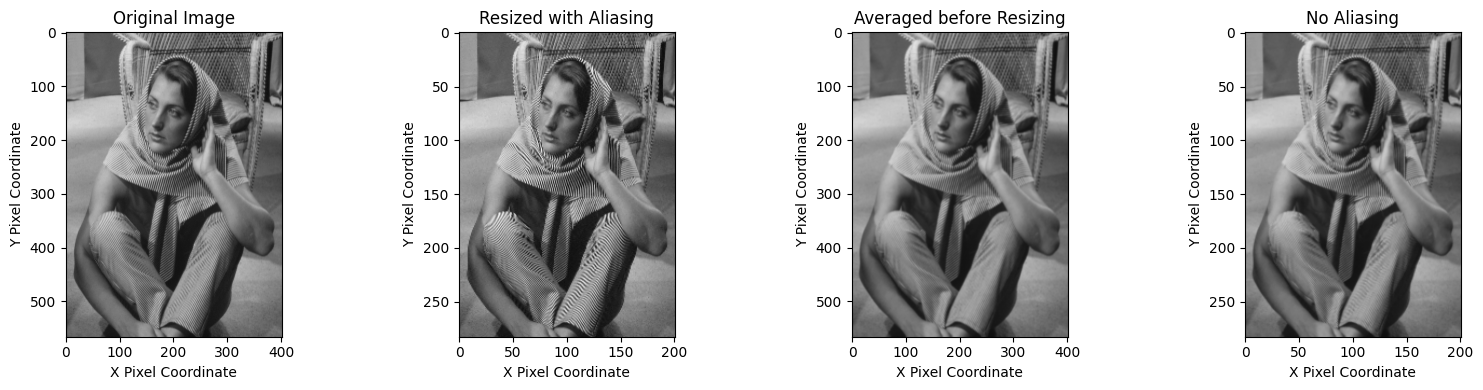

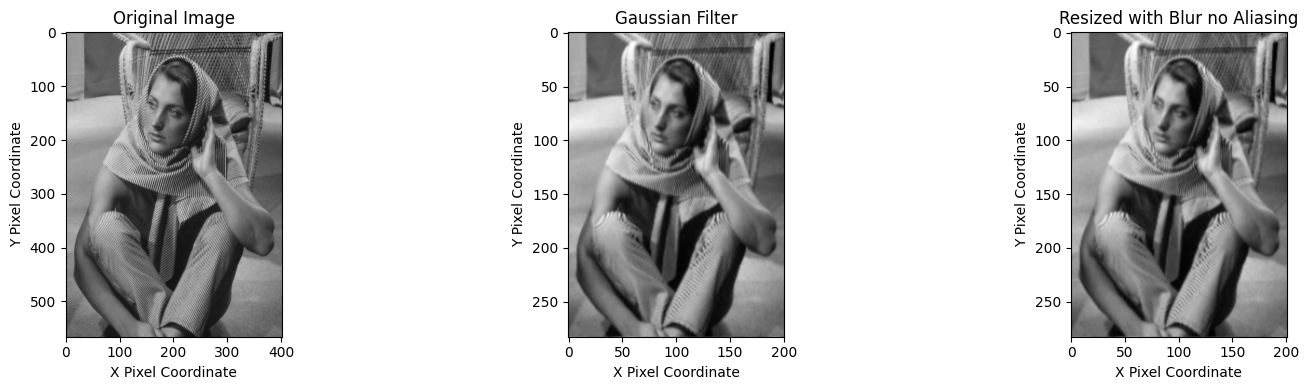

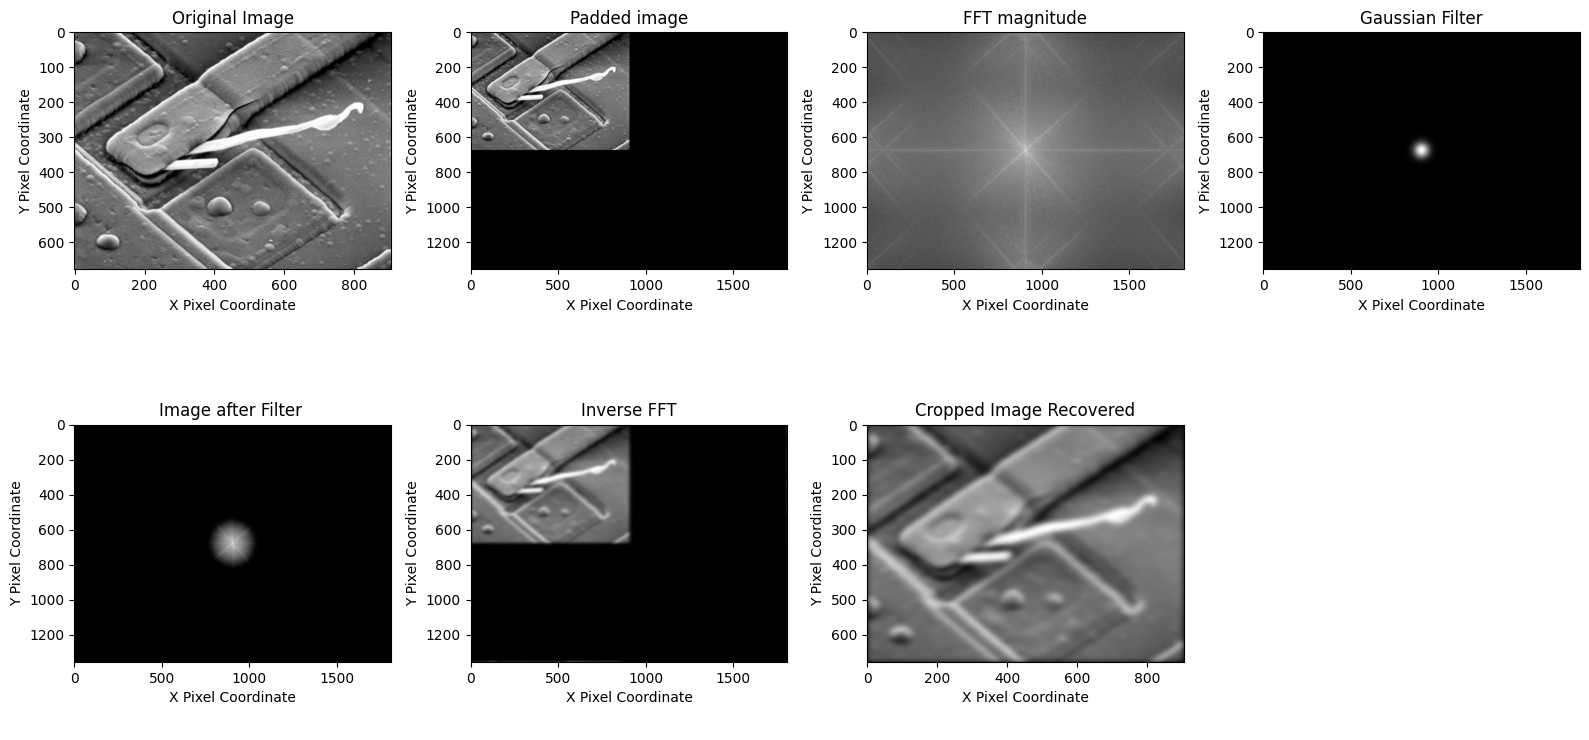

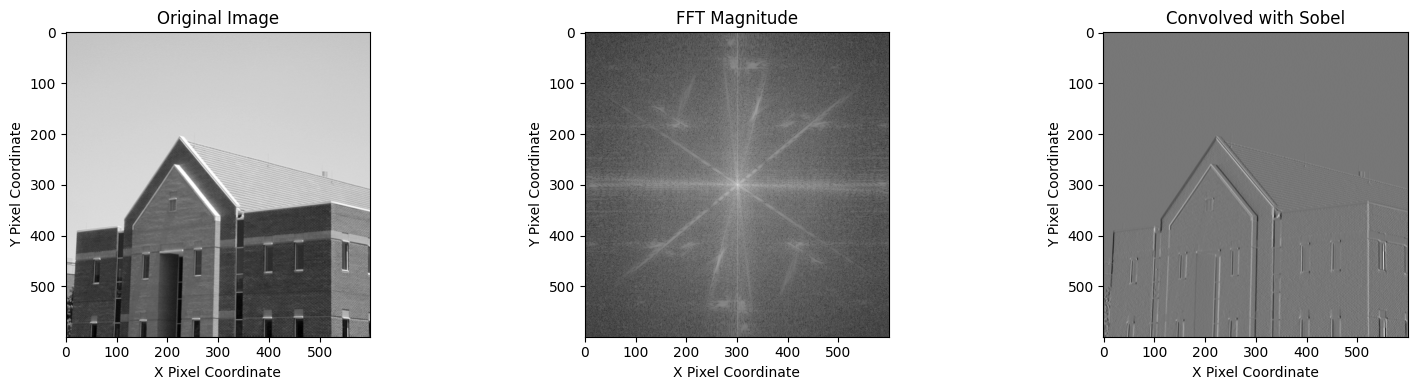

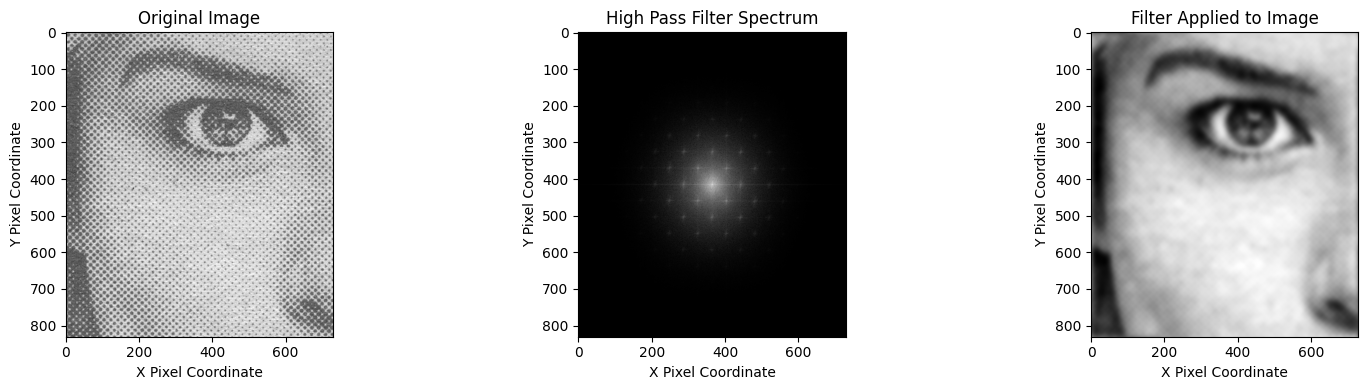

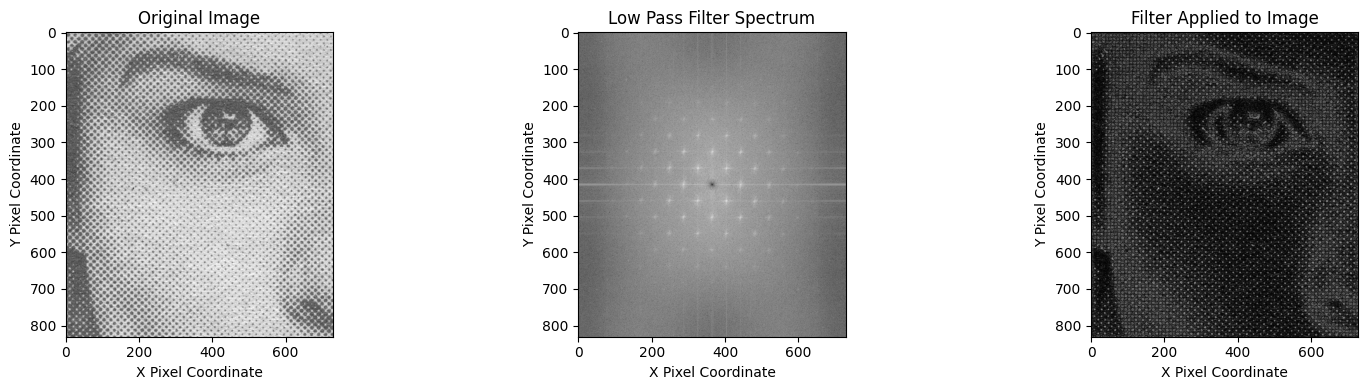

In [ ]:
# Question 5 -> image rescaling (showing aliasing) -> a) compensate by first applying 3x3 averaging filter then resize b) apply FFT method

def resize_nearest_neighbor(image, new_height, new_width):
    """
    Resize image using nearest neighbor interpolation
    This is the simplest method - just picks the closest pixel
    """
    old_height, old_width = image.shape[:2]
    is_rgb = len(image.shape) == 3
    
    # Create output array
    if is_rgb:
        resized = np.zeros((new_height, new_width, 3), dtype=image.dtype)
    else:
        resized = np.zeros((new_height, new_width), dtype=image.dtype)
    
    # Calculate scaling factors
    row_scale = old_height / new_height
    col_scale = old_width / new_width
    
    # For each pixel in the output image
    for i in range(new_height):
        for j in range(new_width):
            # Map to source coordinates
            src_i = int(i * row_scale)
            src_j = int(j * col_scale)
            
            # Clamp to valid range
            src_i = min(src_i, old_height - 1)
            src_j = min(src_j, old_width - 1)
            
            # Copy pixel value
            resized[i, j] = image[src_i, src_j]
    
    return resized

def uniform_neighbourhood_averaging(image_array, m):
    height, width, pixel_array_size = image_array.shape
    average_array = np.zeros((height, width, pixel_array_size), dtype=np.uint8)
    
    for y in range(0, height, 1):
        for x in range(0, width, 1):
            num_pixels = 0
            p_array = []

            for y_m in range(0, m, 1):
                for x_m in range(0, m, 1):
                    check = clamp_vals((x + x_m), (y + y_m), width, height)
                    if check == True:
                        p_array.append(image_array[(y + y_m), (x + x_m)])
                        num_pixels += 1

            s = calc_average(p_array, num_pixels) 
            average_array[y, x] = s

            if average_array[y, x].ndim == 0:  # grayscale pixel
                average_array[y, x] = np.uint8(np.clip(s, 0, 255))
            else:  # color pixel (length-3 array)
                average_array[y, x] = np.clip(average_array[y, x], 0, 255).astype(np.uint8)
    
    return average_array

def clamp_vals(x_test, y_test, width, height):
    val_x = val_y = True

    if x_test >= width:
        val_x = False
    if x_test < 0:
        val_x = False
    if y_test >= height:
        val_y = False
    if y_test < 0:
        val_y = False

    if (val_x == False) or (val_y == False):
        return False
    else:
        return True

def calc_average(array_region, num_pixels):
    if isinstance(array_region, np.ndarray):
        # If it's a numpy array (3D image), extract R channel
        gray_values = array_region[:, :, 0]   # take R channel
        # Flatten to 1D for histogram
        gray_values = gray_values.flatten()
    else:
        # If it's a list of pixels, extract R channel (first element) from each pixel
        gray_values = [int(pixel[0]) for pixel in array_region]

    R = 1/num_pixels
    sum = 0

    for val in gray_values:
        sum = sum + val
    
    average_value = np.uint8(R * sum)
    return average_value

def gaussian_lowpass_filter(image, sigma):
    rows, cols = image.shape[:2]
    crow, ccol = rows // 2, cols // 2 # get center 
    y, x = np.ogrid[:rows, :cols]
    distance_squared = (x - ccol)**2 + (y - crow)**2
    gaussian_filter = np.exp(-distance_squared / (2 * sigma**2))
    f_transform = np.fft.fft2(image[:, :, 0])
    f_shift = np.fft.fftshift(f_transform)
    f_filtered = f_shift * gaussian_filter
    f_ishift = np.fft.ifftshift(f_filtered)
    filtered = np.abs(np.fft.ifft2(f_ishift))
    
    return filtered

def shift_array(array_region, height, width): 
    f_shift = np.zeros((height, width, 1), dtype=np.uint8)
    x_array = np.arange(width).reshape(-1, 1)
    y_array = np.arange(height).reshape(-1, 1)
    # f_complex = np.complex128(array_region)
    for y in y_array:
        for x in x_array:
            f_shift[y, x] = np.uint8(np.clip(array_region[y, x] * ((-1) ** (x+y)), 0, 255))

    return f_shift

    # Euler's expression e^(j*theta) = cos(theta)+jsin(theta)
    # (-1)^(x+y) = e^(j*pi*(x+y))

def FFT_first_principles(image):
    """
    Compute a 2D FFT from first principles using a separable 1D FFT.

    This implementation:
    - Works on a single-channel (grayscale) 2D array
    - Assumes each dimension is a power of 2
    - Matches the unnormalised definition used by np.fft.fft2
    """
    # Ensure complex type
    image = np.asarray(image, dtype=complex)

    # If an image with channels is passed (H, W, C), take the first channel
    if image.ndim == 3:
        image = image[:, :, 0]

    rows, cols = image.shape
    result = image.copy()

    # 2D DFT: X[k,l] = ΣΣ x[m,n] · e^(-2πi(km/M + ln/N))
    # Key insight: This can be separated into:
    # 1. FFT along each row (fixing m, varying n)
    # 2. FFT along each column (fixing n, varying m)
    
    # This has time complexity O(n^2) which means it becomes infintely more complex
    # for u in range(height):
    #     for v in range(width):
    #         for y in range(height):
    #             for x in range(width):
    #                 F[u, v] += f[y, x]*np.exp(-2j*np.pi*(u*x/height + v*y/width))

    # rows_fft = np.zeros_like(x, dtype=complex)
    # for i in range(x.shape[0]):
    #     rows_fft[i, :] = perform_FFT(x[i, :])

    # cols_fft = np.zeros_like(rows_fft, dtype=complex)
    # for j in range(x.shape[1]):
    #     cols_fft[:, j] = perform_FFT(rows_fft[:, j])

    # 1D FFT along rows
    for i in range(rows):
        # Work on a copy of the row to avoid any weird view/stride issues
        result[i, :] = perform_fft_1d(result[i, :].copy())

    # 1D FFT along columns
    for j in range(cols):
        result[:, j] = perform_fft_1d(result[:, j].copy())

    return result

def perform_fft_1d(x):
    x = np.asarray(x, dtype=complex)
    N = len(x)
    # Require power-of-two length
    if N & (N - 1) != 0:
        raise ValueError("Length of input to perform_fft_1d must be a power of 2")
    # Bit-reversal
    bits = int(np.log2(N))
    for i in range(N):
        j = int(bin(i)[2:].zfill(bits)[::-1], 2)
        if i < j:
            x[i], x[j] = x[j], x[i]
    
    # Butterfly stages
    m = 2
    while m <= N:
        wm = np.exp(-2j * np.pi / m)
        for k in range(0, N, m):
            w = 1
            for j in range(m // 2):
                idx_top = k + j
                idx_bot = k + j + m // 2
                
                t = w * x[idx_bot]
                u = x[idx_top]
                
                x[idx_top] = u + t
                x[idx_bot] = u - t
                
                w *= wm
        m *= 2
    return x

def perform_FFT(x):
    N = len(x)
    if N & (N - 1) != 0:
        raise ValueError("N must be power of 2")
    
    bits = int(np.log2(N))
    for i in range(N):
        j = bit_reverse(i, bits)
        if i < j:
            x[i], x[j] = x[j], x[i]

    stage = 1
    length = 2

    while length <= N:
        # Twiddle factor for this stage
        angle = -2j * np.pi / length
        w = np.exp(angle)
        
        # Process all blocks of this size
        for start in range(0, N, length):
            wn = 1
            for k in range(length // 2):
                # Butterfly operation
                a_idx = start + k
                b_idx = start + k + length // 2
                
                a = x[a_idx]
                b = x[b_idx]
                
                t = wn * b
                x[a_idx] = a + t
                x[b_idx] = a - t
                
                wn *= w

        stage += 1
        length *= 2

    return x
    
def bit_reverse(n, bits):
    # """Reverse the bits of n"""
    result = 0
    for i in range(bits):
        result = (result << 1) | (n & 1)
        n >>= 1
    return result

    # # Example
    # print("="*60)
    # x = [1, 2, 3, 4, 5, 6, 7, 8]
    # result = fft_iterative_explained(x.copy())
    # print("="*60)
    # print(f"Final result: {result}")
    # ```

    # ## **7. Understanding Bit Reversal**

    # The bit-reversal step reorders the input to match the recursive decomposition:
    # ```
    # N=8 example:

    # Index (binary) → Reversed → New Index
    # 0 (000)        → 000      → 0
    # 1 (001)        → 100      → 4
    # 2 (010)        → 010      → 2
    # 3 (011)        → 110      → 6
    # 4 (100)        → 001      → 1
    # 5 (101)        → 101      → 5
    # 6 (110)        → 011      → 3
    # 7 (111)        → 111      → 7

    # Original: [x₀, x₁, x₂, x₃, x₄, x₅, x₆, x₇]
    # Reordered: [x₀, x₄, x₂, x₆, x₁, x₅, x₃, x₇]

    # This matches the order from recursive splits

def resize_image_padding(image_array, height, width, ratio):
    P = height * ratio
    Q = width * ratio
    # padded_image_array = np.zeros((P, Q, 1), dtype=np.uint8)

    # for y in range(0, P):
    #     for x in range(0, Q):
    #         if (x < width and y < height):
    #             padded_image_array[y][x] = np.uint8(np.clip(image_array[y][x], 0, 255))
    #         # else:
    #         #     padded_image_array[i][j].append(np.uint(0)) # <- redundant

    # Find factor of 2
    # P = 2 ** int(np.ceil(np.log2(height)))
    # Q = 2 ** int(np.ceil(np.log2(width)))
    P = 2 * height
    Q = 2 * width

    padded_image_array = np.zeros((P, Q, 1), dtype=np.uint8)
    for y in range(0, P):
        for x in range(0, Q):
            if (x < width and y < height):
                padded_image_array[y][x] = np.uint8(np.clip(image_array[y][x], 0, 255))

    return padded_image_array, P ,Q

def norm(image):
    return cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def create_2d_gaussian_filter(P, Q, sigma):
    """
    Create 2D Gaussian filter in frequency domain
    
    shape: (height, width)
    sigma: controls cutoff frequency
    """
    rows, cols = P, Q
    crow, ccol = rows // 2, cols // 2
    
    # Create coordinate grids
    y, x = np.ogrid[:rows, :cols]
    
    # Distance from center
    distance_squared = (x - ccol)**2 + (y - crow)**2
    
    # 2D Gaussian filter
    gaussian = np.exp(-distance_squared / (2 * sigma**2))
    
    return gaussian

def convolve2d(image, kernel, convolve_type):
    """Manual 2D convolution"""
    # Get dimensions
    img_height, img_width = image.shape
    kernel_size = kernel.shape[0]
    pad = kernel_size // 2
    
    # Pad the image to handle borders
    padded = np.pad(image, pad, mode='edge')

    # Output array
    if convolve_type == "gaussian":
        output = np.zeros_like(image)
    elif convolve_type == "laplace" or convolve_type == "sobel":
        output = np.zeros_like(image, dtype=np.float64)
    
    # Perform convolution
    for i in range(img_height):
        for j in range(img_width):
            # Extract region
            region = padded[i:i+kernel_size, j:j+kernel_size]
            # Apply kernel (element-wise multiply and sum)
            output[i, j] = np.sum(region * kernel)
    
    return output

def highpass_filter(P, Q, d0, n):
    rows, cols = P, Q
    crow, ccol = rows // 2, cols // 2
    
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt((x - ccol)**2 + (y - crow)**2)
    
    # Avoid division by zero
    distance = np.where(distance == 0, 0.01, distance)
    
    # Butterworth high-pass
    butterworth = 1 - (1 / (1 + (d0 / distance)**(2 * n)))
    
    return butterworth
    
def lowpass_filter(P, Q, d0, n):
    rows, cols = P, Q
    crow, ccol = rows // 2, cols // 2
    
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt((x - ccol)**2 + (y - crow)**2)
    
    # Avoid division by zero
    distance = np.where(distance == 0, 0.01, distance)
    
    # Butterworth high-pass
    butterworth = 1 / (1 + (d0 / distance)**(2 * n))
    H = 1 / (1 + (d0 / distance)**(2 * n))
    
    return butterworth

def sobel_to_frequency(image_shape):
    """
    Convert Sobel kernels to frequency domain
    
    Key steps:
    1. Create Sobel kernels (3×3)
    2. Pad to image size
    3. Apply FFT
    4. Shift to center
    """
    
    # Step 1: Create Sobel kernels
    sobel_x = np.array([
        [-1,  0,  1],
        [-2,  0,  2],
        [-1,  0,  1]
    ], dtype=np.float64)
    
    sobel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float64)

    rows, cols = image_shape
    
    # Create padded kernels
    sobel_x_padded = np.zeros((rows, cols))
    sobel_y_padded = np.zeros((rows, cols))
    
    # Place 3×3 kernel at top-left
    sobel_x_padded[:3, :3] = sobel_x
    sobel_y_padded[:3, :3] = sobel_y
    
    # Step 3: Apply FFT
    sobel_x_freq = np.fft.fft2(sobel_x_padded)
    sobel_y_freq = np.fft.fft2(sobel_y_padded)

    # Step 4: Shift to center (for visualization)
    sobel_x_freq_shifted = np.fft.fftshift(sobel_x_freq)
    sobel_y_freq_shifted = np.fft.fftshift(sobel_y_freq)
    
    return {
        'sobel_x_freq': sobel_x_freq,
        'sobel_y_freq': sobel_y_freq,
        'sobel_x_freq_shifted': sobel_x_freq_shifted,
        'sobel_y_freq_shifted': sobel_y_freq_shifted
    }

def apply_sobel_frequency(image):
    """
    Apply Sobel filter in frequency domain
    
    This is equivalent to spatial domain convolution
    but can be faster for large images
    """
    
    # Handle RGB
    if len(image.shape) == 3:
        # Apply to each channel separately
        gx_total = np.zeros_like(image, dtype=np.float64)
        gy_total = np.zeros_like(image, dtype=np.float64)
        
        for c in range(3):
            gx, gy, mag, _ = apply_sobel_frequency(image[:, :, c])
            gx_total[:, :, c] = gx
            gy_total[:, :, c] = gy
        
        magnitude = np.sqrt(gx_total**2 + gy_total**2)
        direction = np.arctan2(gy_total, gx_total)
        
        return gx_total, gy_total, magnitude, direction
    
    # Step 1: Create Sobel kernels
    sobel_x = np.array([
        [-1,  0,  1],
        [-2,  0,  2],
        [-1,  0,  1]
    ], dtype=np.float64)
    
    sobel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float64)
    
    # Step 2: Pad kernels to image size
    rows, cols = image.shape
    sobel_x_padded = np.zeros((rows, cols))
    sobel_y_padded = np.zeros((rows, cols))
    sobel_x_padded[:3, :3] = sobel_x
    sobel_y_padded[:3, :3] = sobel_y
    
    # Step 3: FFT of image
    image_freq = np.fft.fft2(image)
    
    # Step 4: FFT of kernels
    sobel_x_freq = np.fft.fft2(sobel_x_padded)
    sobel_y_freq = np.fft.fft2(sobel_y_padded)
    
    # Step 5: Multiply in frequency domain (= convolution in spatial)
    gx_freq = image_freq * sobel_x_freq
    gy_freq = image_freq * sobel_y_freq
    
    # Step 6: Inverse FFT to get back to spatial domain
    gx = np.fft.ifft2(gx_freq).real
    gy = np.fft.ifft2(gy_freq).real
    
    # Step 7: Compute magnitude and direction
    magnitude = np.sqrt(gx**2 + gy**2)
    direction = np.arctan2(gy, gx)
    
    return gx, gy, magnitude, direction

def select_question(question):
    match question:
        case "5a":
            image_path = 'Figures/aliasing.png' 
            image_array = cv2.imread(image_path)
            height, width,_ = image_array.shape

            # resize_image(image_path, T_inv)
            aliased_image = resize_nearest_neighbor(image_array, round(height/2), round(width/2))
            average = uniform_neighbourhood_averaging(image_array, 3)
            no_aliasing = resize_nearest_neighbor(average, round(height/2), round(width/2))

            # Plot
            fig, axes = plt.subplots(1, 4, figsize=(16, 4))

            axes[0].imshow(image_array, cmap='gray')
            axes[0].set_title('Original Image')
            axes[0].set_xlabel("X Pixel Coordinate")
            axes[0].set_ylabel("Y Pixel Coordinate")

            axes[1].imshow(aliased_image, cmap='gray')
            axes[1].set_title("Resized with Aliasing")
            axes[1].set_xlabel("X Pixel Coordinate")
            axes[1].set_ylabel("Y Pixel Coordinate")

            axes[2].imshow(average, cmap='gray')
            axes[2].set_title("Averaged before Resizing")
            axes[2].set_xlabel("X Pixel Coordinate")
            axes[2].set_ylabel("Y Pixel Coordinate")

            axes[3].imshow(no_aliasing, cmap='gray')
            axes[3].set_title("No Aliasing")
            axes[3].set_xlabel("X Pixel Coordinate")
            axes[3].set_ylabel("Y Pixel Coordinate")

            plt.tight_layout()
            plt.show()
            plt.close(fig)

        case "5b":
            image_path = 'Figures/aliasing.png' 
            image_array = cv2.imread(image_path)
            height, width,_ = image_array.shape

            # resize_image(image_path, T_inv)
            aliased_image = resize_nearest_neighbor(image_array, round(height/2), round(width/2))
            sigma = 50
            gaussian_filter = gaussian_lowpass_filter(aliased_image, sigma)
            no_aliasing = resize_nearest_neighbor(gaussian_filter, round(height/2), round(width/2))

            # Plot
            fig, axes = plt.subplots(1, 3, figsize=(16, 4))

            axes[0].imshow(image_array, cmap='gray')
            axes[0].set_title('Original Image')
            axes[0].set_xlabel("X Pixel Coordinate")
            axes[0].set_ylabel("Y Pixel Coordinate")

            axes[1].imshow(gaussian_filter, cmap='gray')
            axes[1].set_title("Gaussian Filter")
            axes[1].set_xlabel("X Pixel Coordinate")
            axes[1].set_ylabel("Y Pixel Coordinate")

            axes[2].imshow(no_aliasing, cmap='gray')
            axes[2].set_title("Resized with Blur no Aliasing")
            axes[2].set_xlabel("X Pixel Coordinate")
            axes[2].set_ylabel("Y Pixel Coordinate")

            plt.tight_layout()
            plt.show()
            plt.close(fig)

        case "6a":
            image_path = 'Figures/FFT.png' 
            image_array = cv2.imread(image_path)
            height, width,_ = image_array.shape
            # plt.imshow(image_array, cmap='gray')
            # plt.show()

            ratio = 2
            is_h_pow2 = (height & (height - 1)) == 0
            is_w_pow2 = (width & (width - 1)) == 0

            # Using libraries ############################################
            # Apply 2D FFT
            
            # Pad to next power-of-two in *either* dimension if needed
            if not (is_h_pow2 and is_w_pow2):
                P = ratio * height
                Q = ratio * width
                image_array = np.pad(image_array[:, :, 0], ((0, P - height), (0, Q - width)), mode='constant')

            plt.imshow(image_array, cmap='gray')
            plt.show()

            # Shift zero frequency to center
            spectrum = np.fft.fft2(image_array)
            spectrum_shifted = np.fft.fftshift(spectrum)

            plt.imshow(np.abs(spectrum_shifted), cmap='gray')
            plt.show()
            
            # Compute magnitude spectrum
            magnitude = np.abs(spectrum_shifted)
            
            # Log scale for better visualization
            magnitude_log = np.log1p(magnitude)
            
            # Phase spectrum
            phase = np.angle(spectrum_shifted)

            magnitude_display = (magnitude_log / magnitude_log.max() * 255).astype(np.uint8)
            plt.imshow(magnitude_display, cmap='gray')
            plt.show()

            ############################################

        case "6b":
            image_path = 'Figures/FFT.png' 
            image_array = cv2.imread(image_path)
            height, width,_ = image_array.shape
            # plt.imshow(image_array, cmap='gray')
            # plt.show()

            ratio = 2
            is_h_pow2 = (height & (height - 1)) == 0
            is_w_pow2 = (width & (width - 1)) == 0

            # Pad to the next power-of-two sizes for custom FFT as well
            if not (is_h_pow2 and is_w_pow2):
                image_array, height, width = resize_image_padding(image_array[:, :, 0], height, width, ratio)
                # plt.imshow(image_array, cmap='gray')
                # plt.show()

            shifted_array = shift_array(image_array, height, width)

            # Our own 2D FFT (expects 2D grayscale or single-channel padded image)
            f_fft_spectrum = FFT_first_principles(shifted_array)
            spectrum_image = np.abs(f_fft_spectrum)

            # Enhance with log
            magnitude_log = np.log1p(spectrum_image)
            magnitude_display = (magnitude_log / magnitude_log.max() * 255).astype(np.uint8)

            phase = np.angle(f_fft_spectrum)

            # plt.imshow(magnitude_display, cmap='gray')
            # plt.show()

        case "6_working":
            image_path = 'Figures/FFT.png' 
            image_array = cv2.imread(image_path)
            height, width,_ = image_array.shape

            array_vals = image_array[:, :, 0]
            
            P, Q = 2 * height, 2 * width
            fp = np.zeros((P, Q))
            fp[:height, :width] = array_vals

            y, x = np.indices((P, Q))
            centering_mask = np.power(-1, x + y)
            fp_centered = fp * centering_mask
            # plt.imshow(fp_centered, cmap='gray')
            # plt.show()
            
            fft_result = np.fft.fft2(fp_centered)

            spec_mag = np.log(1 + np.abs(fft_result))
            image_result = norm(spec_mag)

            # Gaussian filter
            sigma = 30
            H = create_2d_gaussian_filter(P, Q, sigma)

            G_freq = fft_result * H
            g_spec_mag = np.log(1 + np.abs(G_freq))
            image_result_H = norm(g_spec_mag)

            # Inverse
            gp_centered = np.real(np.fft.ifft2(G_freq))
            gp = gp_centered * centering_mask
            image_result_fft = norm(gp)

            g = gp[:height, :width]
            image_result_cropped = norm(g)

            # Plot
            fig, axes = plt.subplots(2, 4, figsize=(16, 8))

            axes[0][0].imshow(array_vals, cmap='gray')
            axes[0][0].set_title('Original Image')
            axes[0][0].set_xlabel("X Pixel Coordinate")
            axes[0][0].set_ylabel("Y Pixel Coordinate")

            axes[0][1].imshow(fp, cmap='gray')
            axes[0][1].set_title("Padded image")
            axes[0][1].set_xlabel("X Pixel Coordinate")
            axes[0][1].set_ylabel("Y Pixel Coordinate")

            axes[0][2].imshow(image_result, cmap='gray')
            axes[0][2].set_title("FFT magnitude")
            axes[0][2].set_xlabel("X Pixel Coordinate")
            axes[0][2].set_ylabel("Y Pixel Coordinate")

            axes[0][3].imshow(H, cmap='gray')
            axes[0][3].set_title("Gaussian Filter")
            axes[0][3].set_xlabel("X Pixel Coordinate")
            axes[0][3].set_ylabel("Y Pixel Coordinate")

            axes[1][0].imshow(image_result_H, cmap='gray')
            axes[1][0].set_title('Image after Filter ')
            axes[1][0].set_xlabel("X Pixel Coordinate")
            axes[1][0].set_ylabel("Y Pixel Coordinate")

            axes[1][1].imshow(image_result_fft, cmap='gray')
            axes[1][1].set_title("Inverse FFT")
            axes[1][1].set_xlabel("X Pixel Coordinate")
            axes[1][1].set_ylabel("Y Pixel Coordinate")

            axes[1][2].imshow(image_result_cropped, cmap='gray')
            axes[1][2].set_title("Cropped Image Recovered")
            axes[1][2].set_xlabel("X Pixel Coordinate")
            axes[1][2].set_ylabel("Y Pixel Coordinate")

            axes[1][3].axis("off")

            plt.tight_layout()
            plt.show()
            plt.close(fig)
        
        case "7":
            image_path = 'Figures/equivalence_1.png' 
            image_array = cv2.imread(image_path)
            height, width,_ = image_array.shape
           
            y, x = np.indices((height, width))
            centering_mask = np.power(-1, x + y)
            fp_centered = image_array[:, :, 0] * centering_mask
            
            fft_result = np.fft.fft2(fp_centered)

            spec_mag = np.log(1 + np.abs(fft_result))
            image_result = norm(spec_mag)

            # Spatial example
            A, B = height, width
            kernel = np.array([ [-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float64)
            filtered_x = convolve2d(image_array[:, :, 0], kernel, convolve_type="sobel")
            
            # Plot
            fig, axes = plt.subplots(1, 3, figsize=(16, 4))

            axes[0].imshow(image_array, cmap='gray')
            axes[0].set_title('Original Image')
            axes[0].set_xlabel("X Pixel Coordinate")
            axes[0].set_ylabel("Y Pixel Coordinate")

            axes[1].imshow(image_result, cmap='gray')
            axes[1].set_title("FFT Magnitude")
            axes[1].set_xlabel("X Pixel Coordinate")
            axes[1].set_ylabel("Y Pixel Coordinate")

            axes[2].imshow(filtered_x, cmap='gray')
            axes[2].set_title("Convolved with Sobel")
            axes[2].set_xlabel("X Pixel Coordinate")
            axes[2].set_ylabel("Y Pixel Coordinate")

            plt.tight_layout()
            plt.show()
            plt.close(fig)

        case "8":
            image_path = 'Figures/butterworth_filters.png' 
            image_array = cv2.imread(image_path)
            height, width,_ = image_array.shape

            fft_result = np.fft.fft2(image_array[:, :, 0])
            f_shift = np.fft.fftshift(fft_result)

            # Highpass filter
            d0 = 20
            n = 2
            # height = width = 128
            H = highpass_filter(height, width, d0, n)
            filtered_spectrum = f_shift * H
            h_spec_mag = np.log(1 + np.abs(filtered_spectrum))
            image_result = norm(h_spec_mag)
            
            # Step 4: Inverse shift
            f_ishift = np.fft.ifftshift(filtered_spectrum)
            
            # Step 5: Inverse FFT
            filtered_image = np.fft.ifft2(f_ishift)
            
            # Take real part (imaginary should be ~0)
            norm_image = np.abs(filtered_image)

            # Plot
            fig, axes = plt.subplots(1, 3, figsize=(16, 4))

            axes[0].imshow(image_array, cmap='gray')
            axes[0].set_title('Original Image')
            axes[0].set_xlabel("X Pixel Coordinate")
            axes[0].set_ylabel("Y Pixel Coordinate")

            axes[1].imshow(image_result, cmap='gray')
            axes[1].set_title("High Pass Filter Spectrum")
            axes[1].set_xlabel("X Pixel Coordinate")
            axes[1].set_ylabel("Y Pixel Coordinate")

            axes[2].imshow(norm_image, cmap='gray')
            axes[2].set_title("Filter Applied to Image")
            axes[2].set_xlabel("X Pixel Coordinate")
            axes[2].set_ylabel("Y Pixel Coordinate")

            plt.tight_layout()
            plt.show()
            plt.close(fig)
   
            # Low-pass filter
            d0 = 20
            n = 2
            H = lowpass_filter(height, width, d0, n)

            filtered_spectrum = f_shift * H
            h_spec_mag = np.log(1 + np.abs(filtered_spectrum))
            image_result = norm(h_spec_mag)
            
            # Step 4: Inverse shift
            f_ishift = np.fft.ifftshift(filtered_spectrum)
            
            # Step 5: Inverse FFT
            filtered_image = np.fft.ifft2(f_ishift)
            
            # Take real part (imaginary should be ~0)
            norm_image = np.abs(filtered_image)

            # Plot
            fig, axes = plt.subplots(1, 3, figsize=(16, 4))

            axes[0].imshow(image_array, cmap='gray')
            axes[0].set_title('Original Image')
            axes[0].set_xlabel("X Pixel Coordinate")
            axes[0].set_ylabel("Y Pixel Coordinate")

            axes[1].imshow(image_result, cmap='gray')
            axes[1].set_title("Low Pass Filter Spectrum")
            axes[1].set_xlabel("X Pixel Coordinate")
            axes[1].set_ylabel("Y Pixel Coordinate")

            axes[2].imshow(norm_image, cmap='gray')
            axes[2].set_title("Filter Applied to Image")
            axes[2].set_xlabel("X Pixel Coordinate")
            axes[2].set_ylabel("Y Pixel Coordinate")

            plt.tight_layout()
            plt.show()
            plt.close(fig)


def main():
    question_list = ["5a", "5b", "6_working", "7", "8"]
    for question in question_list:
        select_question(question)

if __name__ == "__main__":
    main()

## 2. Segmentation
Using the Berkley Segmentation Dataset, Mean Shift Segmentation, Normalised Cut Segmentation, and Expectation Maximisation Segmentation was explored.
### 2.1 Mean Shift Segmentation

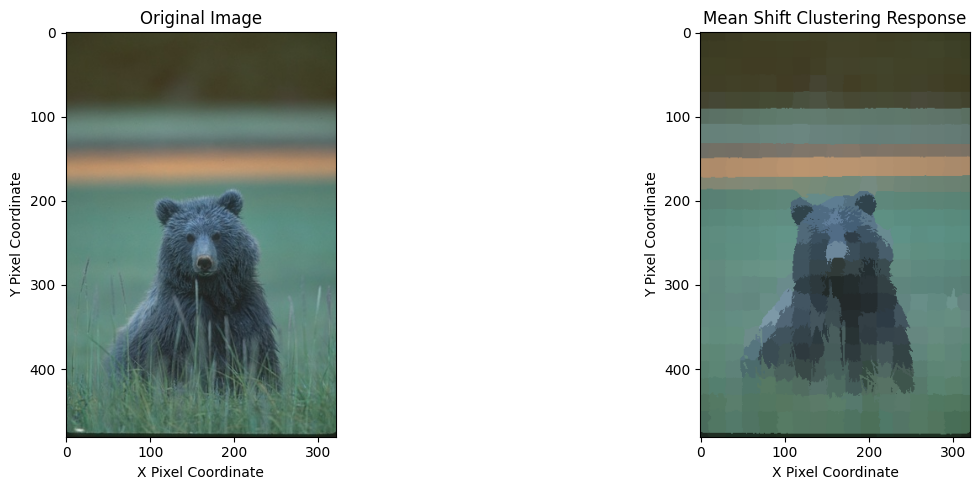

In [ ]:
# Image segmentation using mean shift in joint spatial-color domain.
# Based on Section 4.2.1 of the paper.

# Args:
#     image: H × W × 3 RGB image (values 0-255)
#     spatial_bandwidth: h_s (spatial resolution)
#     color_bandwidth: h_r (color resolution)
#     min_region_size: Minimum pixels per region

# Returns:
#     segmented_image: Segmented image
#     labels: Cluster label for each pixel


# h_s = spatial bandwidth
# h_r = colour_bandwidth

def gaussian_kernel(distance, bandwidth):
    return np.exp(-0.5 * (distance / bandwidth) ** 2)

def image_to_features(image):
    image_luv = rgb2luv(image / 255.0)
    height, width, pixel_array_size = image.shape
    n_pixels = height * width

    features = np.zeros((n_pixels, 5))
    idx = 0
    for i in range(0, height):
        for j in range(0, width):
            idx = i * width + j
            features[idx] = [i, j, image_luv[i, j, 0], image_luv[i, j, 1], image_luv[i, j, 2]]
            idx += 1

    return height, width, n_pixels, features

def create_grid_space(height, width, grid_size, features):
    grid_indices = []
    grid_features = []
    for i in range(0, height, grid_size):
        for j in range(0, width, grid_size):
            idx = i * width + j
            grid_features.append(features[idx])
            grid_indices.append(idx)
    
    grid_features = np.array(grid_features)

    return grid_features, grid_indices

def mean_shift_filter(features, h_s, h_r, max_iter=100, tol=0.1):
    n_points = features.shape[0]
    modes = np.zeros_like(features)

    for i in range(n_points):
        mode = mean_shift_filter_point(features[i], features, h_s, h_r, max_iter, tol)
        modes[i] = mode

    return modes

def mean_shift_filter_point(start_point, features, h_s, h_r, max_iter=100, tol=0.1):
    current = start_point.copy()

    for iteration in range(max_iter): # usually converges between 5-30 iterations -> safety net
        new_point, shift = mean_shift_step(current, features, h_s, h_r)
        if shift < 0.1: # small tolerance
                break

        current = new_point

    return current

def mean_shift_step(current_point, features, h_s, h_r):
    spatial_current = current_point[:2]
    color_current = current_point[2:]

    spatial_features = features[:, :2]
    color_features = features[:, 2:]

    spatial_distance = np.linalg.norm(spatial_features - spatial_current[:2], axis=1) # calculate distance from current point to each data point
    colour_distance = np.linalg.norm(color_features - color_current[2:], axis = 1) # calculate colour distance from current point to each data point

    spatial_weights = gaussian_kernel(spatial_distance, h_s)
    color_weights = gaussian_kernel(colour_distance, h_r)

    weights = spatial_weights * color_weights

    weight_sum = np.sum(weights)
    if weight_sum == 0:
        return current_point, 0
    
    weights = weights/weight_sum # calc average
    new_point = np.sum(features * weights[:, np.newaxis], axis = 0)

    # check converegence
    shift = np.linalg.norm(new_point - current_point)

    return current_point, shift

def delineate_clusters(modes, h_s, h_r):
    # Delineate clusters by grouping pixels with similar modes
    #Delineate the clusters by grouping together all data points that are closer than h_s in spatial domain and h_r in range domain
    n_points = modes.shape[0]
    labels = -np.ones(n_points, dtype=int)
    cluster_centers = []
    cluster_id = 0

    for i in range(n_points):
        if labels[i] == -1:
            spatial_diff = np.linalg.norm(modes[:, :2] - modes[i, :2], axis = 1)
            colour_diff = np.linalg.norm(modes[:, 2:] - modes[i, 2:], axis = 1)

        similar_mask = (spatial_diff < h_s) & (colour_diff < h_r)

        labels[similar_mask] = cluster_id
        cluster_centers.append(modes[i])
        cluster_id += 1
    
    return labels, np.array(cluster_centers)

def create_segmented_image(original_image, labels, height, width):
    segmented = np.zeros_like(original_image)
    labels_2d = labels.reshape(height, width)
    
    for label in np.unique(labels):
        mask = labels_2d == label
        mean_color = original_image[mask].mean(axis=0)
        segmented[mask] = mean_color
    
    return segmented

def mean_shift_image_segment(image, h_s, h_r, min_region_size=20, grid_size=20):
    features = []
    height, width, _, features = image_to_features(image)
    grid_features, _ = create_grid_space(height, width, grid_size, features)
    modes_grid = mean_shift_filter(grid_features, h_s, h_r)
    
    modes = np.zeros_like(features)
    for i, feature in enumerate(features):
        # Find nearest grid mode
        distances = np.linalg.norm(grid_features - feature, axis=1)
        nearest = np.argmin(distances)
        modes[i] = modes_grid[nearest]

    labels, _ = delineate_clusters(modes, h_s, h_r)
    segmented_image = create_segmented_image(image, labels, height, width)

    # Reshape labels to 2D
    labels_2d = labels.reshape(height, width)
    n_clusters = len(np.unique(labels))
    
    return segmented_image, labels_2d, n_clusters

def plot_image(image_path, response, transform_type):
    # Visualize
    image_orig = cv2.imread(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_orig, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].set_xlabel("X Pixel Coordinate")
    axes[0].set_ylabel("Y Pixel Coordinate")

    axes[1].imshow(response, cmap='gray')
    axes[1].set_title(f"{transform_type} Response")
    axes[1].set_xlabel("X Pixel Coordinate")
    axes[1].set_ylabel("Y Pixel Coordinate")

    # axes[2].imshow(image, cmap='gray')
    # y_coords, x_coords = np.where(corners)
    # axes[2].plot(x_coords, y_coords, 'r.', markersize=5)
    # axes[2].set_title('Detected Corners')
    # axes[2].axis('off')
    # Add labels

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def main():
    # Second red region (bottom-right 3x3 square)
    image_path = 'Figures/mean_shift_clustering.png' 
    image = cv2.imread(image_path)

    #h_s -> 5-15
    #h_r -> 5-28

    s_bw = 8
    c_bw = 8

    segmented, labels, clusters = mean_shift_image_segment(image, s_bw, c_bw, min_region_size=20)
    plot_image(image_path, segmented, "Mean Shift Clustering")

if __name__ == "__main__":
    main()

### 2.2 Normalised Cut Segmentation

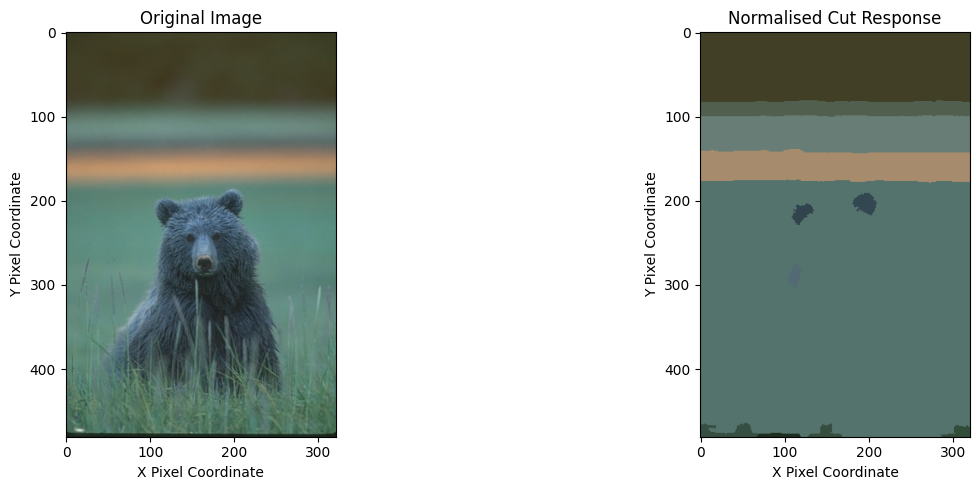

In [ ]:
# Complete normalized cut segmentation pipeline
    
#     Args:
#         image: Input RGB image (H×W×3, values 0-255)
#         sigma_I: Color similarity bandwidth
#         sigma_X: Spatial proximity bandwidth
#         r: Spatial connection radius
#         num_segments: Number of segments (currently supports 2)
    
#     Returns:
#         labels: Segmentation labels (H×W)
#         segmented_image: Segmented image

def build_weight_matrix(image, sigma_I=0.1, sigma_X=4.0, r=5):
    image_lab = rgb2lab(image / 255.0)
    height, width = image.shape[:2]
    n_pixels = height * width
    
    # Store sparse matrix in COO format
    rows = []
    cols = []
    data = []

    for i in range(height):
        for j in range(width):
            idx1 = i * width + j
            # Position and color of pixel (i,j)
            pos1 = np.array([i, j])
            color1 = image_lab[i, j]

            for di in range(-r, r+1):
                for dj in range(-r, r+1):
                    ni, nj = i + di, j + dj

                    # Check bounds
                    if ni < 0 or ni >= height or nj < 0 or nj >= width:
                        continue

                    idx2 = ni * width + nj
                    if idx1 == idx2:
                        continue

                    # Position and color of neighbor
                    pos2 = np.array([ni, nj])
                    color2 = image_lab[ni, nj]

                    # Compute distances
                    spatial_dist = np.linalg.norm(pos1 - pos2)

                    # Only connect if within radius
                    if spatial_dist <= r:
                        color_dist = np.linalg.norm(color1 - color2)

                        # Compute weight (product of two Gaussians)
                        w = np.exp(-color_dist**2 / (2 * sigma_I**2)) * \
                            np.exp(-spatial_dist**2 / (2 * sigma_X**2))
                        
                        rows.append(idx1)
                        cols.append(idx2)
                        data.append(w)

    # Create sparse matrix
    W = csr_matrix((data, (rows, cols)), shape=(n_pixels, n_pixels))
    
    # Make symmetric
    W = (W + W.T) / 2
    
    return W

def compute_normalized_laplacian(W):
    # Degree vector
    D = np.array(W.sum(axis=1)).flatten()
    
    # FIX 4: Add small epsilon to all degrees
    # Prevents division by zero AND near-singular matrices
    epsilon = 1e-8
    D = D + epsilon
    
    # D^(-1/2)
    D_inv_sqrt = 1.0 / np.sqrt(D)
    
    # Create sparse diagonal matrices
    D_inv_sqrt_sparse = diags(D_inv_sqrt)
    D_sparse = diags(D)
    
    # Normalized Laplacian: D^(-1/2) (D - W) D^(-1/2)
    # = I - D^(-1/2) W D^(-1/2)
    n = W.shape[0]
    I = diags(np.ones(n))
    
    # D^(-1/2) W D^(-1/2)
    D_inv_sqrt_W = D_inv_sqrt_sparse @ W @ D_inv_sqrt_sparse
    
    L_norm = I - D_inv_sqrt_W
    
    return L_norm, D, D_inv_sqrt

def compute_ncut_eigenvectors(W, num_eigenvectors = 2):
    D = np.array(W.sum(axis=1)).flatten()
    D_sparse = csr_matrix(np.diag(D))
    D_sqrt_inv = np.sqrt(1.0 / (D + 1e-10)) 
    L = D_sparse - W
    n = W.shape[0]
    k = min(num_eigenvectors + 2, n - 1)
    L_norm, D, D_inv_sqrt = compute_normalized_laplacian(W)
    
    eigenvalues, eigenvectors = eigsh(
        L_norm,
        k=k,
        sigma=1e-6,      # Slight shift away from 0
        which='LM',       # Largest magnitude near sigma
        tol=1e-6,         # Tolerance
        maxiter=2000      # More iterations
    )

    # Sort by eigenvalue
    idx = eigenvalues.argsort()
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Skip first eigenvector (constant, eigenvalue=0)
    return eigenvalues[1:], eigenvectors[:, 1:]

def partition_from_eigenvector(eigenvector, method="median"):
    if method == 'median':
        threshold = np.median(eigenvector)
    elif method == 'zero':
        threshold = 0
    elif method == 'optimal':
        # Search for best threshold
        threshold = find_optimal_threshold(eigenvector)
    else:
        threshold = 0
    
    labels = (eigenvector > threshold).astype(int)
    
    return labels

def find_optimal_threshold(eigenvector, num_splits=100):
    # Try different thresholds
    min_val, max_val = eigenvector.min(), eigenvector.max()
    thresholds = np.linspace(min_val, max_val, num_splits)
    
    # For simplicity, just use median
    # Full implementation would compute Ncut for each threshold
    return np.median(eigenvector)

def create_segmented_image(image, labels):
    segmented = np.zeros_like(image)
    for label in np.unique(labels):
        mask = labels == label
        mean_color = image[mask].mean(axis=0)
        segmented[mask] = mean_color
    return segmented

def normalized_cut_segmentation(image, sigma_I=0.1, sigma_X=4.0, r=5, num_segments=2):
    height, width = image.shape[:2]
    W = build_weight_matrix(image, sigma_I, sigma_X, r)
    _, eigenvectors = compute_ncut_eigenvectors(W, num_eigenvectors=1)

    second_eigenvector = eigenvectors[:, 0]
    labels_1d = partition_from_eigenvector(second_eigenvector, method='median')
    labels = labels_1d.reshape(height, width)
    segmented_image = create_segmented_image(image, labels)
    
    return labels, segmented_image

def plot_image(image_path, response, transform_type):
    # Visualize
    image_orig = cv2.imread(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_orig, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].set_xlabel("X Pixel Coordinate")
    axes[0].set_ylabel("Y Pixel Coordinate")

    axes[1].imshow(response, cmap='gray')
    axes[1].set_title(f"{transform_type} Response")
    axes[1].set_xlabel("X Pixel Coordinate")
    axes[1].set_ylabel("Y Pixel Coordinate")

    # axes[2].imshow(image, cmap='gray')
    # y_coords, x_coords = np.where(corners)
    # axes[2].plot(x_coords, y_coords, 'r.', markersize=5)
    # axes[2].set_title('Detected Corners')
    # axes[2].axis('off')
    # Add labels

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def main():
    # image = np.zeros((100, 100, 3), dtype=np.uint8)
    # image[:, :50] = [255, 0, 0]  # Red left half
    # image[:, 50:] = [0, 0, 255]  # Blue right half
    
    # # Add noise
    # noise = np.random.randint(-20, 20, image.shape)
    # image = np.clip(image.astype(int) + noise, 0, 255).astype(np.uint8)

    # Second red region (bottom-right 3x3 square)
    image_path = 'Figures/mean_shift_clustering.png' 
    image = cv2.imread(image_path)

    scale = 0.25
    new_shape = (int(image.shape[0] * scale), int(image.shape[1] * scale))
    image_small = (resize(image, new_shape, anti_aliasing=True) * 255).astype(np.uint8)
    
    # My attempt at the algorithm -> did not work
    # labels, segmented = normalized_cut_segmentation(image_small, sigma_I=0.1, sigma_X=4.0, r=5)
  
    # Using a library:
    img = image
    labels1 = segmentation.slic(img, compactness=30, n_segments=400, start_label=1)
    out1 = color.label2rgb(labels1, img, kind='avg', bg_label=0)

    g = graph.rag_mean_color(img, labels1, mode='similarity')
    labels2 = graph.cut_normalized(labels1, g)
    out2 = color.label2rgb(labels2, img, kind='avg', bg_label=0)

    plot_image(image_path, out2, "Normalised Cut")

if __name__ == "__main__":
    main()

### 2.3 Expectation Maximisation Segmentation

/Users/anthea/Documents/GitHub/EAI733/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/Users/anthea/Documents/GitHub/EAI733/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


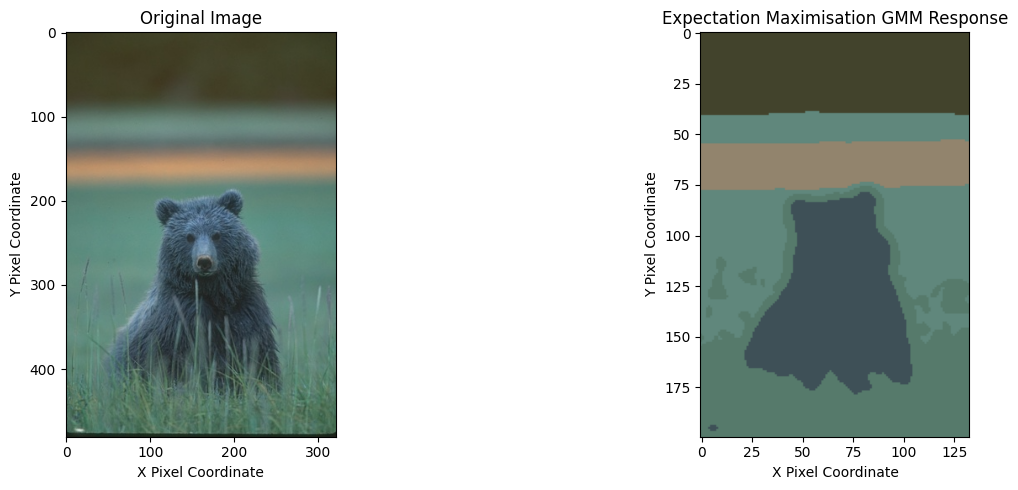

In [ ]:
class BlobworldSegmentation:
    def __init__(self, k_range=(2, 5)):
        self.k_range = k_range
        self.best_k = None
        self.labels = None
        self.features = None
        
    def extract_color_features(self, image, scale = 2.0):
        lab_image = color.rgb2lab(image / 255.0)
        lab_smooth = np.zeros_like(lab_image)
        for i in range(3):
            lab_smooth[:, :, i] = gaussian_filter(lab_image[:, :, i], sigma=scale)
        return lab_smooth

    def extract_texture_features(self, image):
        lab = color.rgb2lab(image/255.0)
        L_channel = lab[:, :, 0]
        dy, dx = np.gradient(L_channel)

        Ixx = gaussian_filter(dx * dx, sigma=2.0)
        Ixy = gaussian_filter(dx * dy, sigma=2.0)
        Iyy = gaussian_filter(dy * dy, sigma=2.0)

        trace = Ixx + Iyy
        det = Ixx * Iyy - Ixy * Ixy

        discriminant = np.maximum(trace**2 - 4*det, 0)  # Ensure non-negative
        lambda1 = (trace + np.sqrt(discriminant)) / 2
        lambda2 = (trace - np.sqrt(discriminant)) / 2
        
        # Avoid division by zero
        eps = 1e-10
        lambda1 = np.maximum(lambda1, eps)
        
        # Texture descriptors
        anisotropy = (lambda1 - lambda2) / lambda1  # 0 to 1
        contrast = 2 * np.sqrt(lambda1 + lambda2)   # Normalized
        
        # Normalize contrast to [0, 1]
        contrast = contrast / (contrast.max() + eps)
        
        # Polarity (simplified - would need full implementation)
        # For simplicity, using a placeholder
        polarity = np.ones_like(anisotropy) * 0.5

        # Modulate by contrast (meaningless in low-contrast regions)
        texture = np.stack([
            anisotropy * contrast,
            polarity * contrast,
            contrast
        ], axis=2)
        
        return texture

    def create_feature_vectors(self, image):
        height, width = image.shape[:2]
        color_features = self.extract_color_features(image)
        texture_features = self.extract_texture_features(image)

        # Create position features (normalized to [0, 1])
        y_coords, x_coords = np.meshgrid(
            np.arange(height) / height,
            np.arange(width) / width,
            indexing='ij'
        )
        position_features = np.stack([y_coords, x_coords], axis=2)
        
        # Concatenate all features
        all_features = np.concatenate([
            color_features,      # L, a, b (3D)
            texture_features,    # anisotropy*c, polarity*c, contrast (3D)
            position_features    # x, y (2D)
        ], axis=2)
        
        # Reshape to (N, 8)
        features = all_features.reshape(-1, 8)
        
        self.height = height
        self.width = width
        
        return features

    def compute_mdl_score(self, gmm, features):
        N = features.shape[0]  # Number of samples
        d = features.shape[1]  # Dimensionality
        K = gmm.n_components  # Number of clusters
        
        # Log likelihood
        log_likelihood = gmm.score(features) * N
        
        # Number of free parameters
        # K-1 (mixing weights) + K*d (means) + K*d*(d+1)/2 (covariances)
        m_k = (K - 1) + K * d + K * d * (d + 1) // 2
        
        # MDL score
        mdl_score = log_likelihood - (m_k / 2) * np.log(N)
        
        return mdl_score

    def fit_em(self, features, K, n_init=4):
        gmm = GaussianMixture(
            n_components=K,
            covariance_type='full',  # Full covariance matrices
            n_init=n_init,
            max_iter=10,
            tol=1e-2,
            random_state=42
        )
        
        gmm.fit(features)
        
        return gmm

    def segment(self, image):
        features = self.create_feature_vectors(image)
        self.features = features

        best_score = -np.inf
        best_gmm = None
        best_k = None

        for K in range(self.k_range[0], self.k_range[1] + 1):
            # print(f"  Trying K={K}...")
            gmm = self.fit_em(features, K)
            mdl_score = self.compute_mdl_score(gmm, features)
            
            # print(f"    MDL score: {mdl_score:.2f}")
            
            if mdl_score > best_score:
                best_score = mdl_score
                best_gmm = gmm
                best_k = K
        
        self.best_k = best_k
        
        # Step 3: Get cluster assignments
        labels_1d = best_gmm.predict(features)
        
        # Step 4: Reshape to image dimensions
        labels = labels_1d.reshape(self.height, self.width)
        
        # Step 5: Post-processing (simplified)
        # In the paper, they do boundary refinement and spatial smoothing
        # For simplicity, we'll just apply median filter
        
        labels = median_filter(labels, size=3)
        
        self.labels = labels
        
        return labels, best_k

    def create_segmented_image(self, image, labels):
        segmented = np.zeros_like(image)
        
        for label in np.unique(labels):
            mask = labels == label
            mean_color = image[mask].mean(axis=0)
            segmented[mask] = mean_color
        
        return segmented

def plot_image(image_path, response, transform_type):
    # Visualize
    image_orig = cv2.imread(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_orig, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].set_xlabel("X Pixel Coordinate")
    axes[0].set_ylabel("Y Pixel Coordinate")

    axes[1].imshow(response, cmap='gray')
    axes[1].set_title(f"{transform_type} Response")
    axes[1].set_xlabel("X Pixel Coordinate")
    axes[1].set_ylabel("Y Pixel Coordinate")

    # axes[2].imshow(image, cmap='gray')
    # y_coords, x_coords = np.where(corners)
    # axes[2].plot(x_coords, y_coords, 'r.', markersize=5)
    # axes[2].set_title('Detected Corners')
    # axes[2].axis('off')
    # Add labels

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def main():
    image_path = 'Figures/mean_shift_clustering.png' 
    image = cv2.imread(image_path)
    if image.shape[0] > 200:
        scale = 200 / image.shape[0]
        new_shape = (int(image.shape[0] * scale), int(image.shape[1] * scale))
        image = (resize(image, new_shape) * 255).astype(np.uint8)

    segmenter = BlobworldSegmentation(k_range=(2, 5))
    labels, n_segments = segmenter.segment(image)
    
    # Create visualization
    segmented = segmenter.create_segmented_image(image, labels)

    plot_image(image_path, segmented, "Expectation Maximisation GMM")

    # Plot results
    # fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # axes[0].imshow(image)
    # axes[0].set_title('Original Image')
    # axes[0].axis('off')
    
    # axes[1].imshow(labels, cmap='tab10')
    # axes[1].set_title(f'Segmentation Labels\n(K={n_segments})')
    # axes[1].axis('off')
    
    # axes[2].imshow(segmented.astype(np.uint8))
    # axes[2].set_title('Segmented Image\n(Mean Colors)')
    # axes[2].axis('off')
    
    # plt.tight_layout()
    # plt.show()

if __name__ == "__main__":
    main()

## 3. Detectors and Descriptors
Two descriptors/detectors are described here - Moravec Corner Detection and Harris Corner Detection.

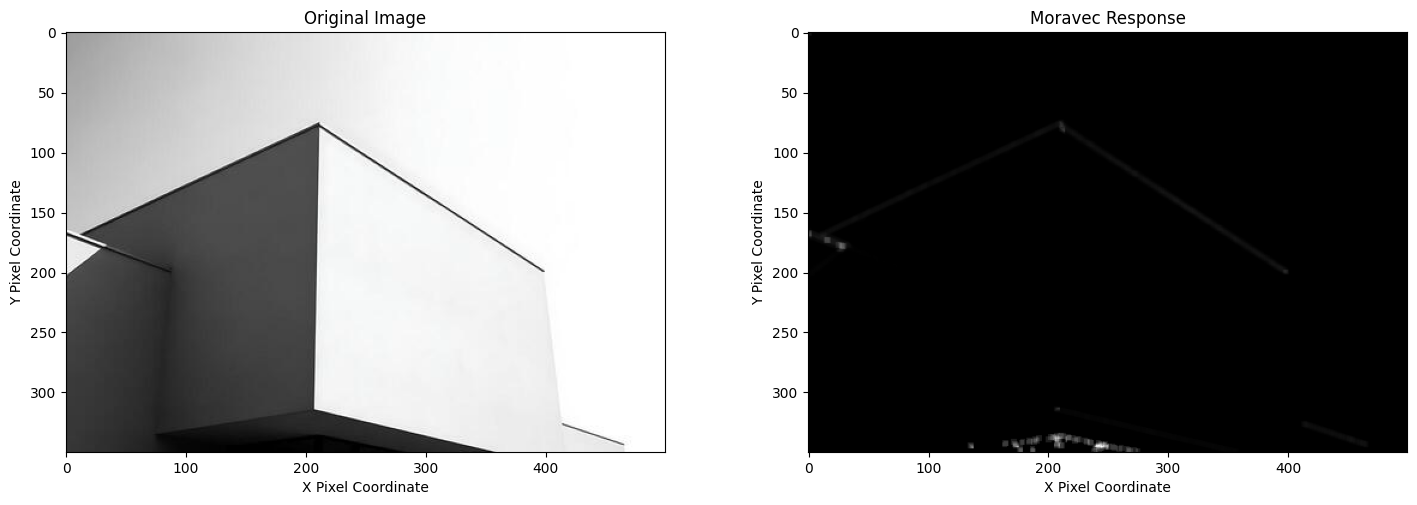

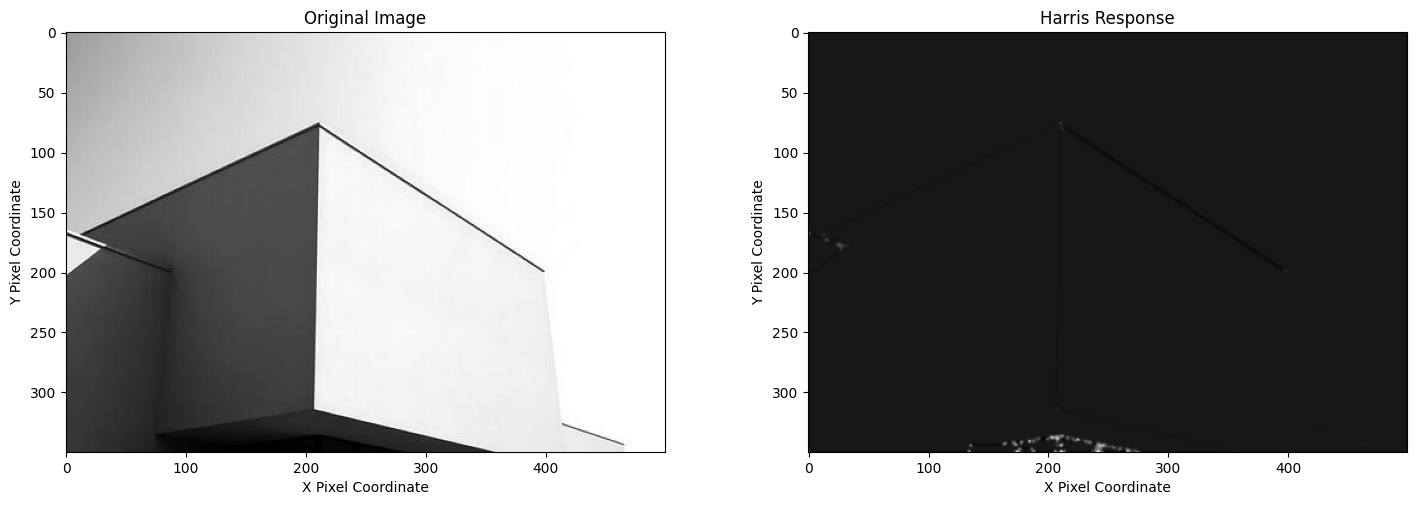

In [ ]:
def select_detector(detector_type):
    match detector_type:
        case "Moravec":
            # Detect corners
            image_path = 'Figures/moravec_building.jpg' 
            image, height, width = prep_image(image_path, detector_type)
            corners, response = moravec_corner_detect(image, height, width, window_size=5, threshold=500)
            plot_image(image_path, response, detector_type) 

        case "Harris":
            image_path = 'Figures/moravec_building.jpg' 
            image, height, width = prep_image(image_path, detector_type)
            corners, response, edges = harris_corner_detect(image, height, width, sigma=1.0, k=0.04, threshold=0.01, window_size=3)
            plot_image(image_path, response, detector_type) 

def prep_image(image_path, detector_type):
    image = cv2.imread(image_path)
    height, width,_ = image.shape
    # save_image(image, f"{detector_type}_original")

    image = (image * 255).astype(np.uint8)
    return image, height, width

def plot_image(image_path, response, detector_type):
    # Visualize
    image_orig = cv2.imread(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_orig, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].set_xlabel("X Pixel Coordinate")
    axes[0].set_ylabel("Y Pixel Coordinate")

    axes[1].imshow(response, cmap='gray')
    axes[1].set_title(f"{detector_type} Response")
    axes[1].set_xlabel("X Pixel Coordinate")
    axes[1].set_ylabel("Y Pixel Coordinate")

    # axes[2].imshow(image, cmap='gray')
    # y_coords, x_coords = np.where(corners)
    # axes[2].plot(x_coords, y_coords, 'r.', markersize=5)
    # axes[2].set_title('Detected Corners')
    # axes[2].axis('off')
    # Add labels

    plt.tight_layout()
    plt.show()
    plt.close()

def moravec_corner_detect(image, height, width, window_size=5, threshold=500 ):
    # height, width = 7, 7
    image_grey = image[:, :, 0]
    half_w = window_size // 2
    window = np.ones((window_size, window_size))

    shifts = [
        (1, 0), # Right
        (1, 1), # Diagonal down-right
        (0, 1), # Down
        (-1, 1) # Diagonal down-left
    ]

    convolve_result = np.zeros((len(shifts), height, width))

    for idx, (dx, dy) in enumerate(shifts):
        shifted = np.roll(image_grey, shift=(dy, dx), axis=(0,1))
        # print(shifted)
        diff_squared = (shifted.astype(float) - image_grey.astype(float)) ** 2
        # print(diff_squared)
        E = convolve(diff_squared, window, mode='constant', cval=0.0)
        # print(E)
        convolve_result[idx] = E
        # print(convolve_result)

    corner_response = np.min(convolve_result, axis=0)
    # print(corner_response)
    local_max = maximum_filter(corner_response, size=3)
    corners = (corner_response == local_max) & (corner_response > threshold)
    return corners, corner_response

def harris_corner_detect(image_rgb, height, width, sigma=1.0, k=0.04, threshold=0.01, window_size=3):
    image = image_rgb[:, :, 0]

    # Ensure float image
    if image.max() > 1.0:
        image = image.astype(float) / 255.0
    else:
        image = image.astype(float)

    Ix = convolve(image, np.array([[-1, 0, 1]]), mode='constant')
    Iy = convolve(image, np.array([[-1], [0], [1]]), mode='constant')
    
    Ixx = Ix * Ix
    Iyy = Iy * Iy
    Ixy = Ix * Iy

    A = gaussian_filter(Ixx, sigma=sigma)  # Smoothed Ix²
    B = gaussian_filter(Iyy, sigma=sigma)  # Smoothed Iy²
    C = gaussian_filter(Ixy, sigma=sigma)  # Smoothed Ix·Iy

    det_M = A * B - C * C           # Determinant: λ₁·λ₂
    trace_M = A + B                  # Trace: λ₁ + λ₂
    
    response = det_M - k * (trace_M ** 2)

    # Corner detection (R > 0)
    corner_threshold = threshold * response.max()
    corner_candidates = response > corner_threshold

    local_max = maximum_filter(response, size=window_size)
    corners = (response == local_max) & corner_candidates

    # Edge detection (R < 0)
    # Edges have negative response
    edge_response = -response  # Flip sign so edges are positive
    edge_threshold = threshold * edge_response.max()
    edge_candidates = edge_response > edge_threshold
    
    # Thin edges: non-maximum suppression along gradient direction
    # Check if local minimum in x or y direction based on gradient magnitude
    gradient_mag = np.sqrt(Ix**2 + Iy**2)
    
    # Simple edge thinning: local minima of response
    local_min_x = np.zeros_like(response, dtype=bool)
    local_min_y = np.zeros_like(response, dtype=bool)
    
    # Check if response is local minimum along x
    for i in range(1, response.shape[0]-1):
        for j in range(1, response.shape[1]-1):
            if np.abs(Ix[i, j]) > np.abs(Iy[i, j]):
                # Dominant gradient in x, check x direction
                if response[i, j] <= response[i, j-1] and \
                   response[i, j] <= response[i, j+1]:
                    local_min_x[i, j] = True
            else:
                # Dominant gradient in y, check y direction
                if response[i, j] <= response[i-1, j] and \
                   response[i, j] <= response[i+1, j]:
                    local_min_y[i, j] = True
    
    edges = (local_min_x | local_min_y) & edge_candidates
    
    return corners, response, edges

def main():
    # Choose detector type
    detector_type =  "Moravec" 
    select_detector(detector_type)
    detector_type = "Harris" 
    select_detector(detector_type)

if __name__ == "__main__":
    main()